# 0. Carga de librerias

In [2]:
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,StratifiedGroupKFold,
                                     GridSearchCV)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors

OUTPUT_DIR_AD   = "resultados dominio de aplicabilidad mordred"
OUTPUT_DIR_ML   = "resultados modelos ML"
OUTPUT_DIR_INT = "resultados interpretabilidad Mordred"
FIGURAS = "figuras/mordred"

# 1. Carga del dataset

In [3]:
df_final = pd.read_csv("Merge_ChEMBL_gallinamides.csv")

## 1.1 Calculo de los descriptores fisicoquimicos a partir de los SMILES etiquetados anteriormente

In [4]:
mols, valid_idx = [], []

print("Convirtiendo SMILES a objetos moleculares...")
for i, row in df_final.iterrows():
    mol = Chem.MolFromSmiles(row["smiles_std"])
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
df_mol = df_final.iloc[valid_idx].reset_index(drop=True)
print(f"Moléculas válidas para Mordred: {len(mols)}")

calc = Calculator(descriptors, ignore_3D=True)
print("Calculando descriptores 2D (esto puede tardar varios minutos)...")
df_desc = calc.pandas(mols)
print(f"Descriptores calculados inicialmente: {df_desc.shape[1]}")

Convirtiendo SMILES a objetos moleculares...
Moléculas válidas para Mordred: 470
Calculando descriptores 2D (esto puede tardar varios minutos)...


 28%|██▊       | 133/470 [00:07<00:26, 12.68it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 29%|██▉       | 137/470 [00:07<00:17, 18.81it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 43%|████▎     | 204/470 [00:10<00:14, 18.22it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 470/470 [00:20<00:00, 23.27it/s]


Descriptores calculados inicialmente: 1613


## 1.2 Limpieza de descriptores

In [5]:
# Columnas vacias
df_desc = df_desc.dropna(axis=1, how="all")
# Columnas con >20% NaN
thresh = int(len(df_desc) * 0.8)
df_desc = df_desc.dropna(axis=1, thresh=thresh)
# Solo columnas numericas
df_desc = df_desc.select_dtypes(include=[np.number])

X_full = df_desc.copy()

y = df_mol["Label_FP2"].values
print(f"Descriptores tras limpieza de columnas (aun sin imputar/filtrar varianza): {X_full.shape[1]}")
print(f"NaN restantes en el dataset (se imputaran solo con datos de train, mas abajo): {int(X_full.isna().sum().sum())}")

X_out = X_full.copy()
X_out.insert(0, "smiles_std", df_mol["smiles_std"].values)
X_out["Label_FP2"] = y
X_out.to_csv(f'{OUTPUT_DIR_ML}/df_descriptores.csv', index=False)
print(f"✅ paso4_descriptores_mordred.csv guardado.")

Descriptores tras limpieza de columnas (aun sin imputar/filtrar varianza): 1375
NaN restantes en el dataset (se imputaran solo con datos de train, mas abajo): 0
✅ paso4_descriptores_mordred.csv guardado.


## 1.3 Separación del dataset en conjuntos

In [6]:
def correlation_filter(X: pd.DataFrame, threshold: float,
                        method: str = "pearson") -> list:
    corr_matrix = X.corr(method=method).abs()
    upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                             )
    to_drop = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained
    
feature_sets = {}   # {"nombre": [lista_columnas_retenidas]}

CORR_THRESHOLDS   = [0.7, 0.8, 0.9]

for thr in CORR_THRESHOLDS:
    for method in ["pearson", "spearman"]:
        key = f"{method}_thr{thr}"
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f"  {key:30s} → {len(retained):4d} descriptores retenidos")

feature_sets["no_filter"] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores (sin filtro)")

pd.DataFrame(
    {"feature_set": list(feature_sets.keys()),
     "n_features":  [len(v) for v in feature_sets.values()]}
).to_csv(f'{OUTPUT_DIR_ML}/paso5_feature_sets.csv', index=False)
print(f"✅ paso5_feature_sets.csv guardado.", sep=';')

  pearson_thr0.7                 →  317 descriptores retenidos
  spearman_thr0.7                →  322 descriptores retenidos
  pearson_thr0.8                 →  420 descriptores retenidos
  spearman_thr0.8                →  426 descriptores retenidos
  pearson_thr0.9                 →  611 descriptores retenidos
  spearman_thr0.9                →  557 descriptores retenidos
  no_filter                      → 1375 descriptores (sin filtro)
✅ paso5_feature_sets.csv guardado.


## 1.4 Desarrollo de los modelos e hiperparámetros

In [7]:
groups_all = X_full.round(6).apply(lambda r: hash(tuple(r)), axis=1)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X_full, y, groups=groups_all))

X_train_full = X_full.iloc[train_idx].reset_index(drop=True)
X_test_full  = X_full.iloc[test_idx].reset_index(drop=True)
y_train      = pd.Series(y).iloc[train_idx].reset_index(drop=True)
y_test       = pd.Series(y).iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")
 
# ── 6.2 Definición de modelos y rejillas de hiperparámetros ───────────────────
# Cada elemento: (nombre, estimador, param_grid)
# Los parámetros del pipeline se prefiján con 'clf__'
 
MODEL_DEFINITIONS = [
    # 1. Regresión Logística
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    # 2. SVM con kernel RBF
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=42),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    # 3. SVM lineal
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=42),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    # 4. K-Nearest Neighbors
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    # 5. Árbol de decisión
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=42),
        {
            "clf__max_depth"       : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"       : ["gini", "entropy"],
        }
    ),
    # 6. Random Forest
    (
        "RandomForest",
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"    : ["sqrt", "log2"],
        }
    ),
    # 7. Extra Trees
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    # 8. Gradient Boosting
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=42),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    # 9. AdaBoost
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    # 10. Red neuronal (MLP)
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=42),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    # 11. Naive Bayes
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    # 12. SGD Classifier
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=42,
                      max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),

    (
        "XGBoost",
        XGBClassifier(random_state=42, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),

    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]

Train: 373 muestras | Test: 97 muestras
  Train activos: 128 (34.3%)
  Test  activos: 39 (40.2%)


In [8]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
 
    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan
 
    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }

# 2. Desarrollo de los modelos de Machine Learning

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
all_results    = []
best_estimators = {}
 
n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos × "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")
 
for fs_name, feat_cols in feature_sets.items():
   # if "pearson_thr0.7" not in fs_name: #comentar esto si se quieren entrenar todos los modelos 
   #     continue
    # Se entrenan los 7 feature sets (pearson/spearman x thr 0.7/0.8/0.9, + no_filter)
    # para poder comparar todos y escoger el mejor modelo global.
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]
 
    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  ▶ {key}")
 
        # Pipeline: imputación → escalado → clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])
 
        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train)
        best_estimators[key] = gs.best_estimator_
 
        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]
 
        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")
 
 
df_results = pd.DataFrame(all_results).sort_values("roc_auc_test", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso6_resultados_todos.csv',sep=";",  index=False)
print(f"\n✅ paso6_resultados_todos.csv guardado.")


Entrenando 14 modelos × 7 feature sets = 98 experimentos...

  ▶ LogisticRegression__pearson_thr0.7
      CV AUC=0.833 | Test AUC=0.796 | Gap=0.122
  ▶ SVM_RBF__pearson_thr0.7
      CV AUC=0.853 | Test AUC=0.845 | Gap=0.216
  ▶ SVM_Linear__pearson_thr0.7
      CV AUC=0.812 | Test AUC=0.798 | Gap=0.084
  ▶ KNeighbors__pearson_thr0.7
      CV AUC=0.847 | Test AUC=0.847 | Gap=0.072
  ▶ DecisionTree__pearson_thr0.7
      CV AUC=0.777 | Test AUC=0.710 | Gap=0.181
  ▶ RandomForest__pearson_thr0.7
      CV AUC=0.864 | Test AUC=0.855 | Gap=0.237
  ▶ ExtraTrees__pearson_thr0.7
      CV AUC=0.868 | Test AUC=0.864 | Gap=0.185
  ▶ GradientBoosting__pearson_thr0.7
      CV AUC=0.865 | Test AUC=0.871 | Gap=0.165
  ▶ AdaBoost__pearson_thr0.7
      CV AUC=0.844 | Test AUC=0.809 | Gap=0.189
  ▶ MLP__pearson_thr0.7
      CV AUC=0.860 | Test AUC=0.815 | Gap=0.226
  ▶ NaiveBayes__pearson_thr0.7
      CV AUC=0.726 | Test AUC=0.682 | Gap=-0.048
  ▶ SGD__pearson_thr0.7
      CV AUC=0.810 | Test AUC=0.754 | 

# 3. Evaluacion y seleccion del modelo 

In [20]:
df_results["score_balanced"] = (
    df_results["roc_auc_test"] - 0.5 * df_results["overfit_gap"].abs()
)
df_results = df_results.sort_values("score_balanced", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso7_resultados_rankeados.csv', sep=";", index=False)

# =============================================================================
# Paso 1: elegir el mejor feature set (threshold)
# =============================================================================
# Para cada feature set (pearson/spearman thr 0.7/0.8/0.9, no_filter) se toma
# el mejor score_balanced alcanzado por CUALQUIERA de los 14 modelos
# entrenados sobre el. Esto responde a "para que threshold los modelos
# funcionan mejor en conjunto", no solo que modelo individual es el mejor.
fs_ranking = (
    df_results.groupby("feature_set")["roc_auc_test"]
    .mean()
    .sort_values(ascending=False)
)
print("\nRanking de feature sets (mejor roc_auc_test alcanzado en cada uno):")
print(fs_ranking.to_string())

best_fs_name = fs_ranking.index[0]
print(f"\nFeature set / threshold elegido: {best_fs_name}")

# =============================================================================
# Paso 2: dentro del feature set ganador, top 3 modelos
# =============================================================================
df_best_fs = (
    df_results[df_results["feature_set"] == best_fs_name]
    .sort_values("score_balanced", ascending=False)
    .reset_index(drop=True)
)
top3 = df_best_fs.head(3)

best_row = top3.iloc[0]
best_key = f"{best_row['model']}__{best_row['feature_set']}"

cols_show = ["model", "feature_set", "n_features", "roc_auc_test", "score_balanced"]
print(f"\nTOP 3 MODELOS DENTRO DE '{best_fs_name}':")
print(top3[cols_show].to_string(index=False))



Ranking de feature sets (mejor roc_auc_test alcanzado en cada uno):
feature_set
pearson_thr0.7     0.809366
no_filter          0.808434
pearson_thr0.8     0.808071
spearman_thr0.8    0.806413
spearman_thr0.9    0.799040
pearson_thr0.9     0.794445
spearman_thr0.7    0.791461

Feature set / threshold elegido: pearson_thr0.7

TOP 3 MODELOS DENTRO DE 'pearson_thr0.7':
           model    feature_set  n_features  roc_auc_test  score_balanced
      KNeighbors pearson_thr0.7         317      0.847259        0.811398
GradientBoosting pearson_thr0.7         317      0.870911        0.788644
      ExtraTrees pearson_thr0.7         317      0.864279        0.771703



## 3.1 Rendimiento por modelo en funcion del threshold (Pearson y Spearman por separado)

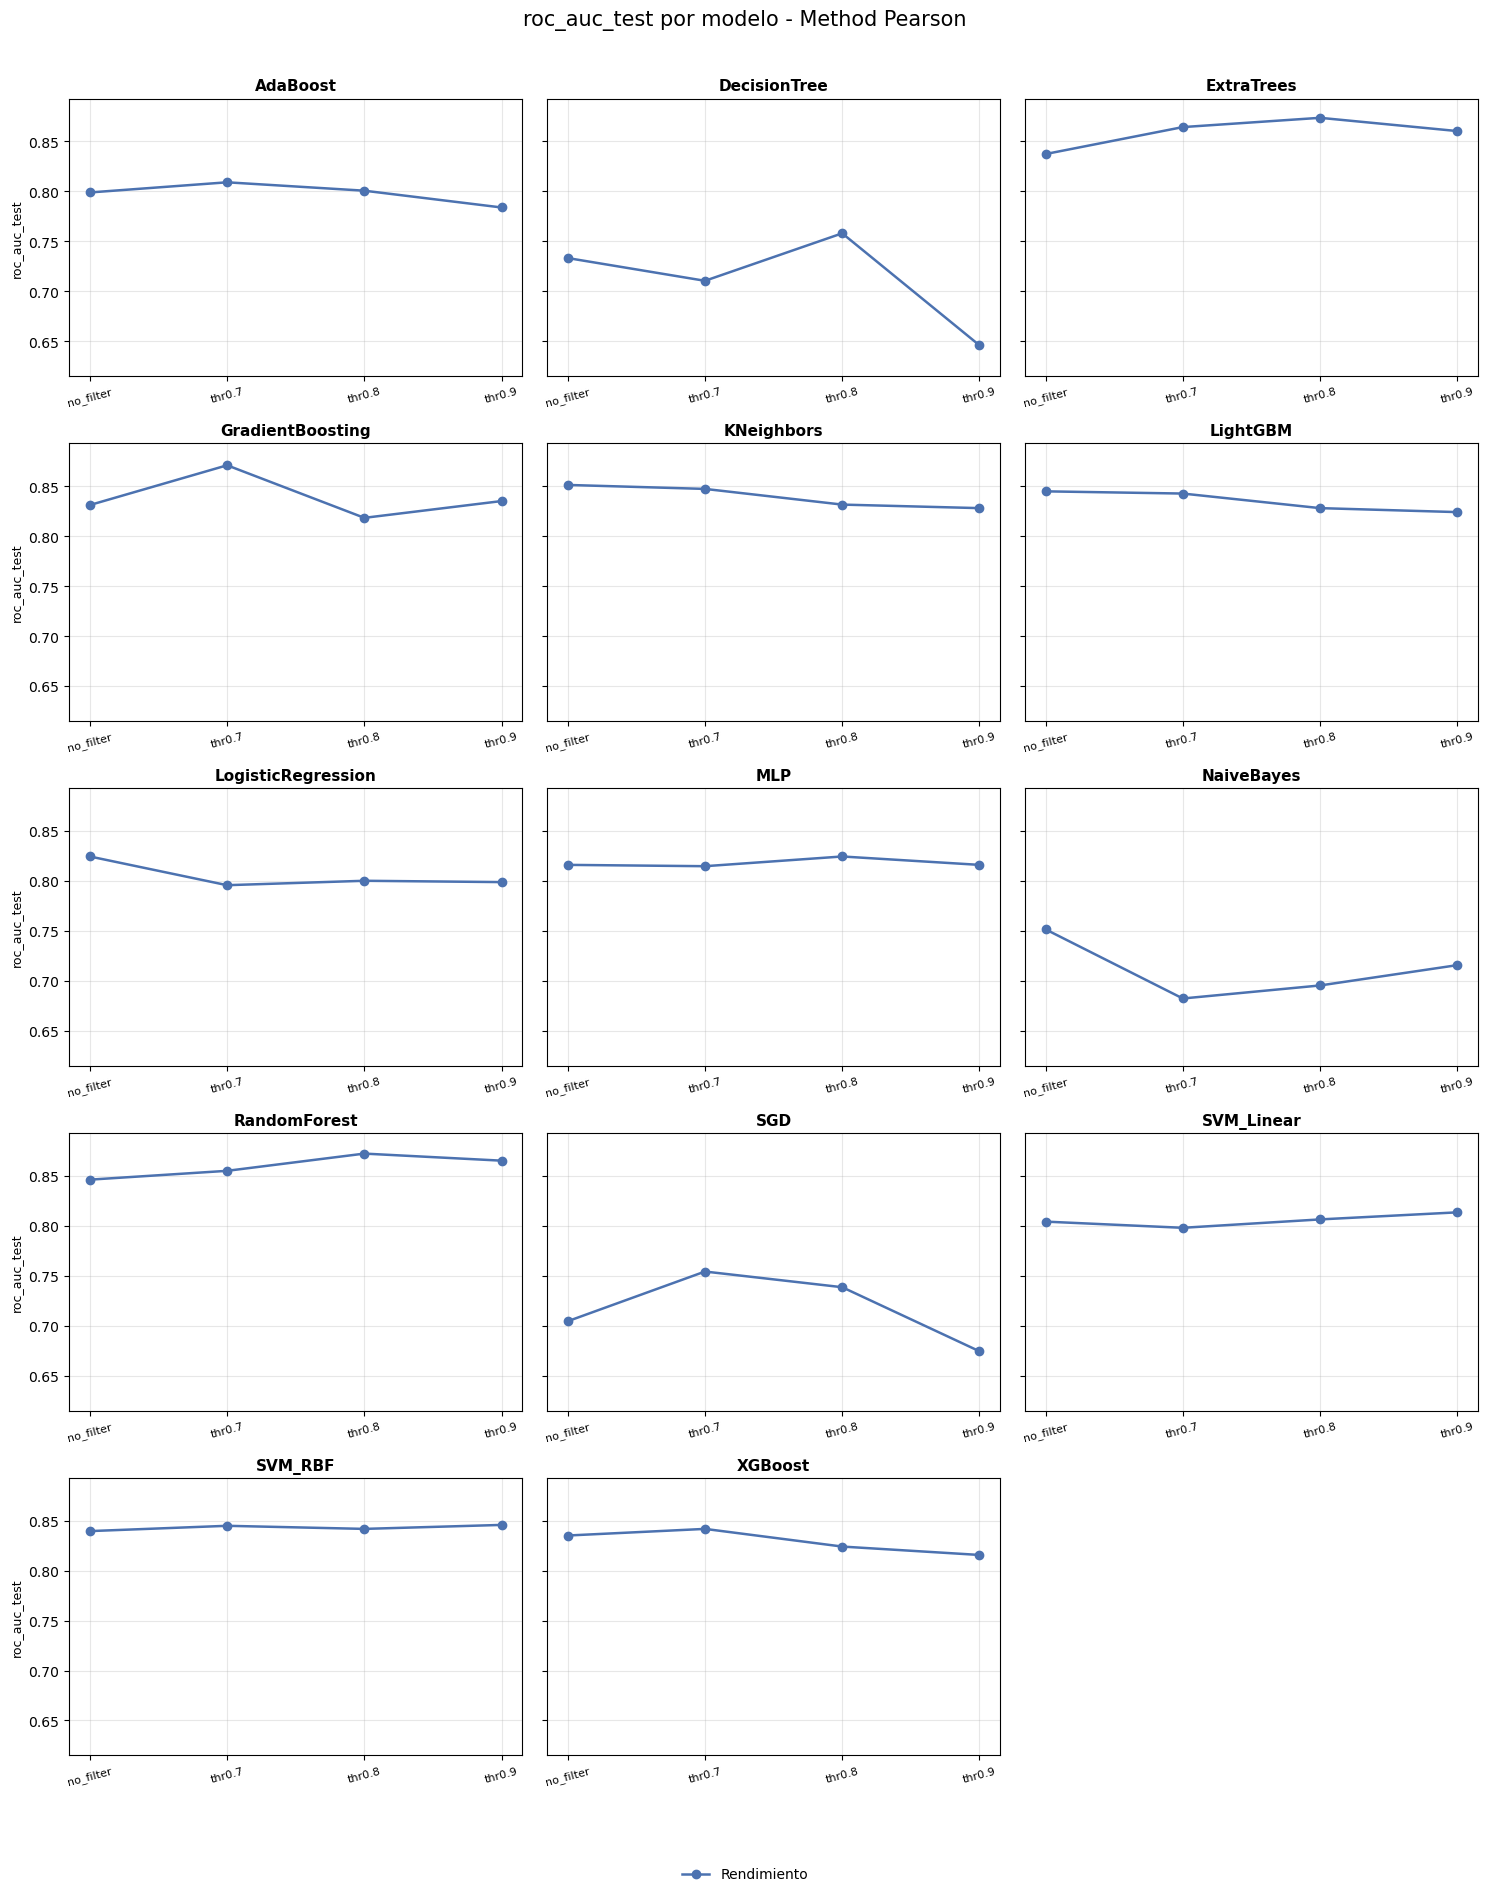

figuras/mordred/paso7b_rendimiento_vs_threshold_pearson_mordred.png guardado.


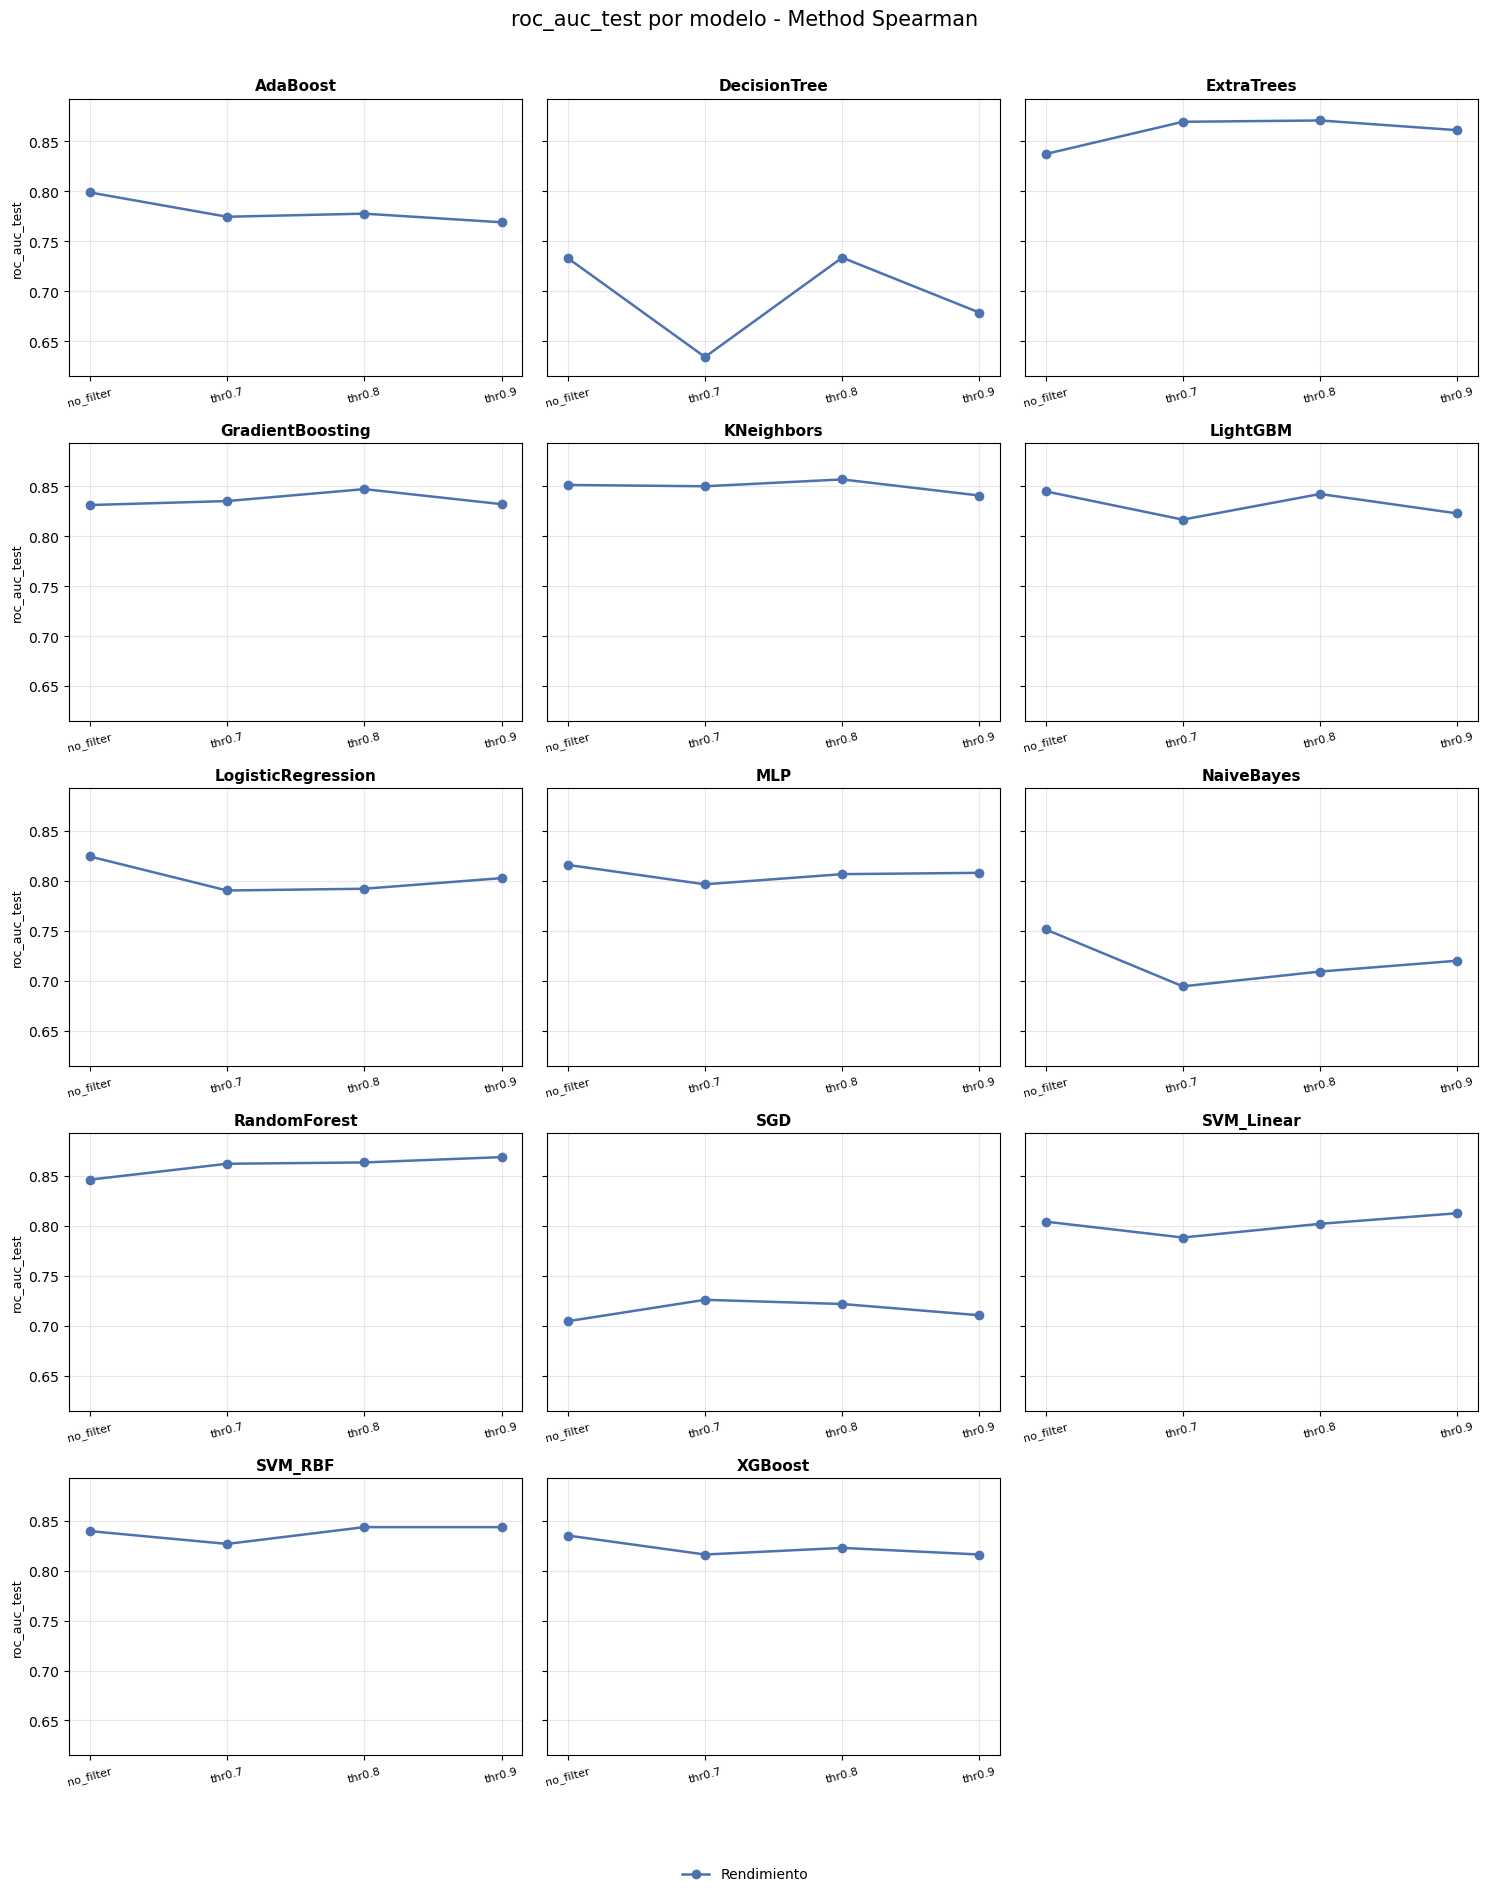

figuras/mordred/paso7b_rendimiento_vs_threshold_spearman_mordred.png guardado.


In [21]:
METRIC_TO_PLOT = "roc_auc_test"   # alternativas: "roc_auc_test", "cv_roc_auc_mean", "mcc_test", "f1_test"

fs_x_order   = ["no_filter", "thr0.7", "thr0.8", "thr0.9"]
pearson_map  = {"no_filter": "no_filter", "thr0.7": "pearson_thr0.7",
                "thr0.8": "pearson_thr0.8", "thr0.9": "pearson_thr0.9"}
spearman_map = {"no_filter": "no_filter", "thr0.7": "spearman_thr0.7",
                 "thr0.8": "spearman_thr0.8", "thr0.9": "spearman_thr0.9"}
models_sorted = sorted(df_results["model"].unique())

# ── Rango global del eje Y (comun a TODOS los subplots de ambas figuras) ────
all_fs_names = list(pearson_map.values()) + list(spearman_map.values())
metric_vals_global = df_results.loc[df_results["feature_set"].isin(all_fs_names), METRIC_TO_PLOT]
y_min, y_max = metric_vals_global.min(), metric_vals_global.max()
y_pad = (y_max - y_min) * 0.08 if y_max > y_min else 0.05
Y_LIM = (y_min - y_pad, y_max + y_pad)
def plot_lineplot_by_method(method_name, fmap):
    cols = 3
    rows = math.ceil(len(models_sorted) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5 + 0.8), sharex=False, sharey=True)
    axes = np.array(axes).reshape(-1)
    for i, model_name in enumerate(models_sorted):
        ax = axes[i]
        sub = df_results[df_results["model"] == model_name]
        y_vals = []
        for x_label in fs_x_order:
            fs_real = fmap[x_label]
            val = sub.loc[sub["feature_set"] == fs_real, METRIC_TO_PLOT]
            y_vals.append(val.values[0] if len(val) > 0 else np.nan)
        ax.plot(fs_x_order, y_vals, marker="o", color="#4C72B0",
                linewidth=1.8, markersize=6, label="Rendimiento")
        ax.set_title(model_name, fontsize=11, fontweight="bold")
        ax.set_ylim(Y_LIM)
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    for r in range(rows):
        axes[r * cols].set_ylabel(METRIC_TO_PLOT, fontsize=9)
    # ── Leyenda unica, debajo de toda la figura ──────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], color="#4C72B0", marker="o", linewidth=1.8, label="Rendimiento"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=False)
    plt.suptitle(f"{METRIC_TO_PLOT} por modelo - Method {method_name}", fontsize=15, y=1.01)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    out_lineplot = f'{FIGURAS}/paso7b_rendimiento_vs_threshold_{method_name.lower()}_mordred.png'
    plt.savefig(out_lineplot, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_lineplot} guardado.")
plot_lineplot_by_method("Pearson", pearson_map)
plot_lineplot_by_method("Spearman", spearman_map)

## 3.2 Realización de las matrices de confusión

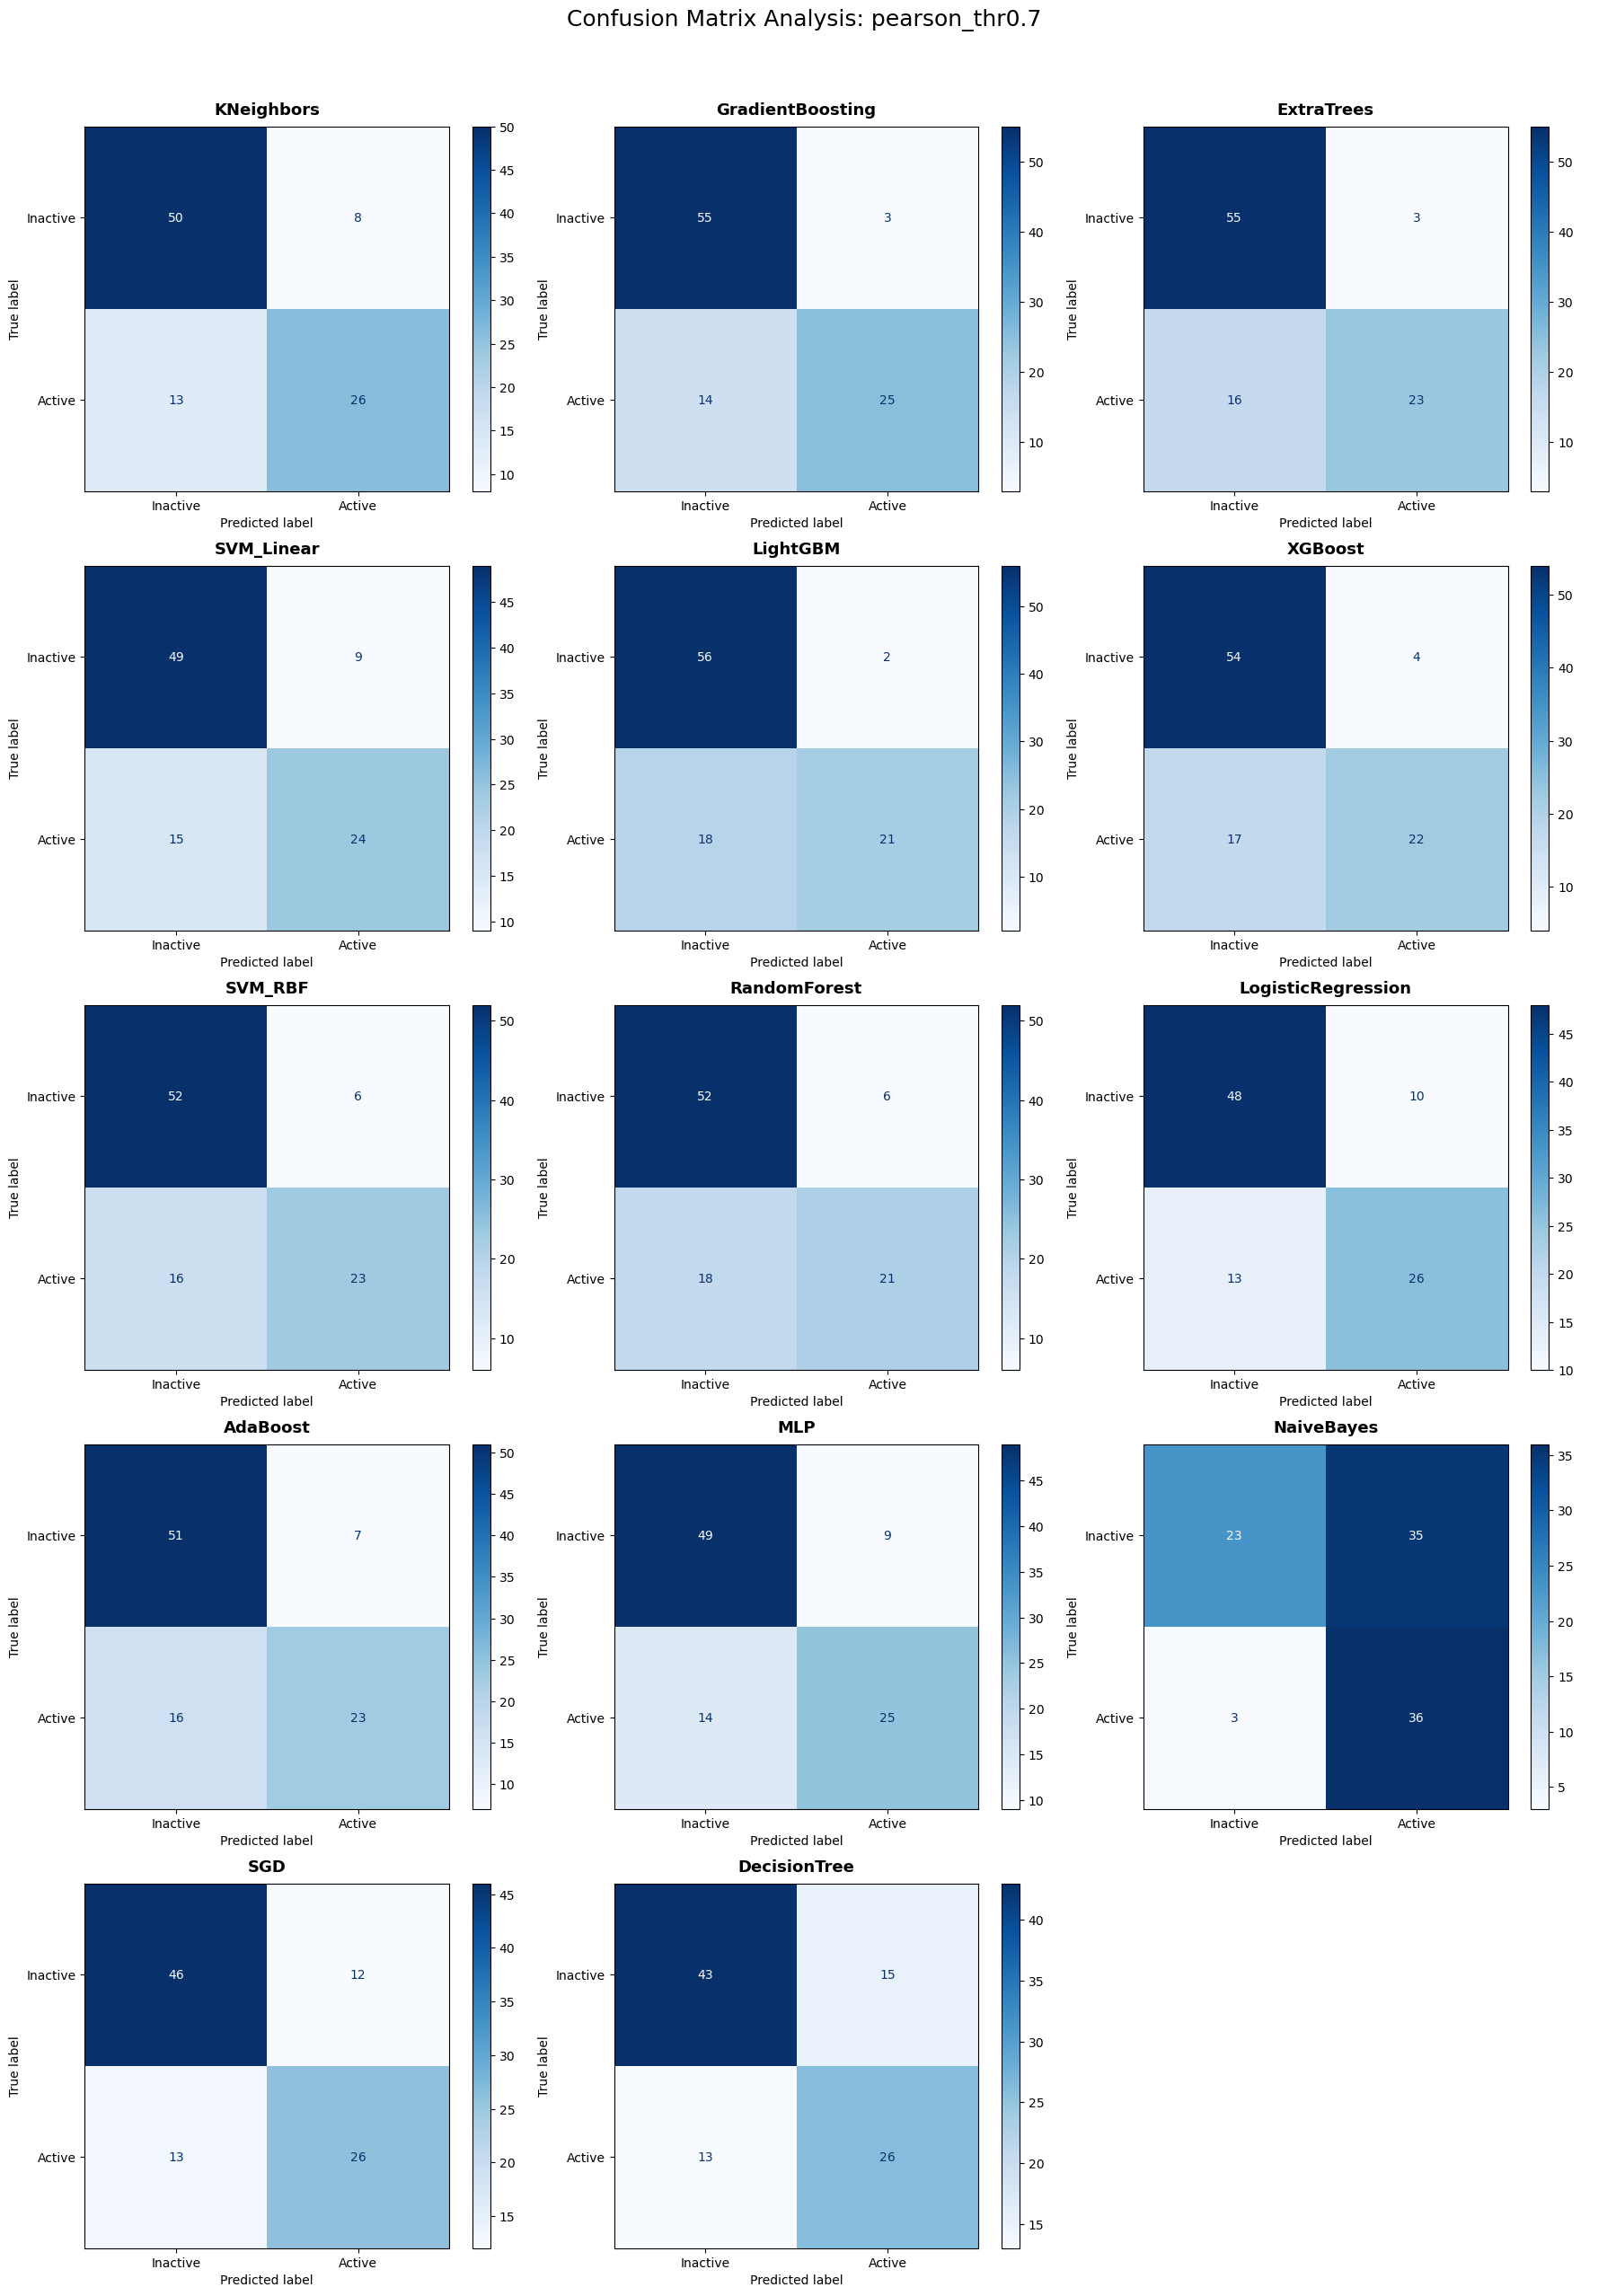

figuras/mordred/paso7_confusion_pearson_thr0.7_mordred.png guardado.


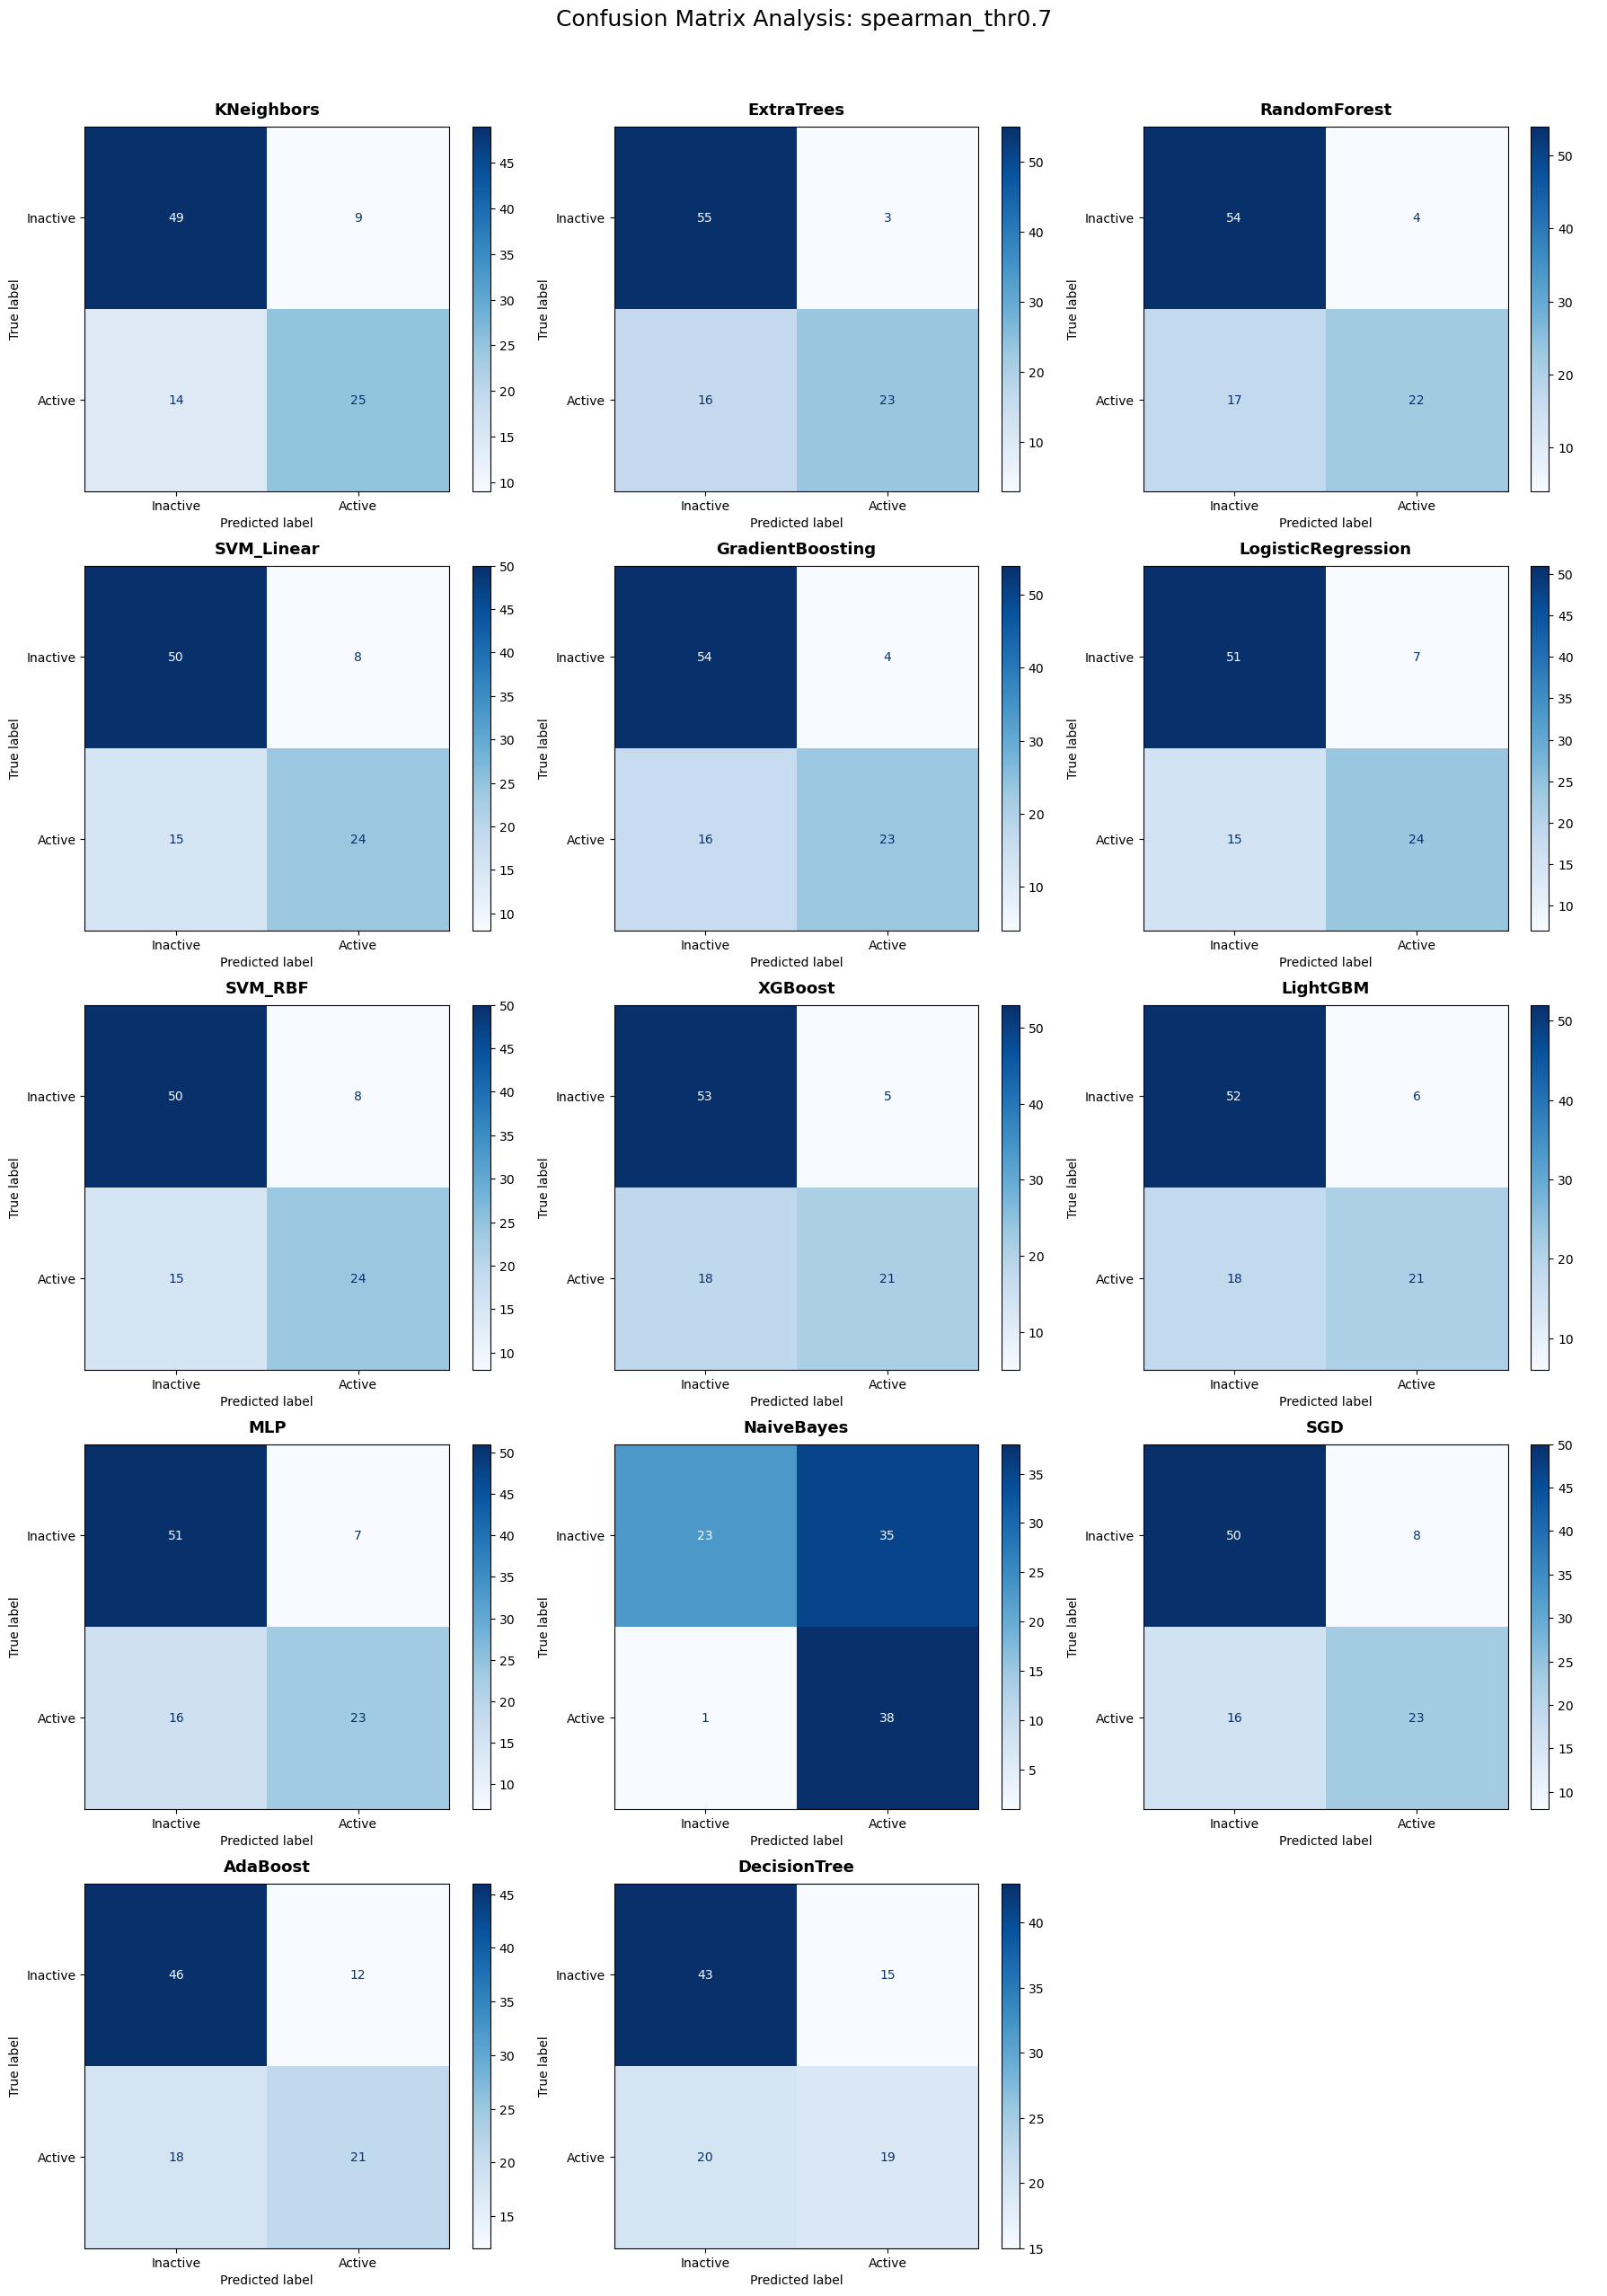

figuras/mordred/paso7_confusion_spearman_thr0.7_mordred.png guardado.


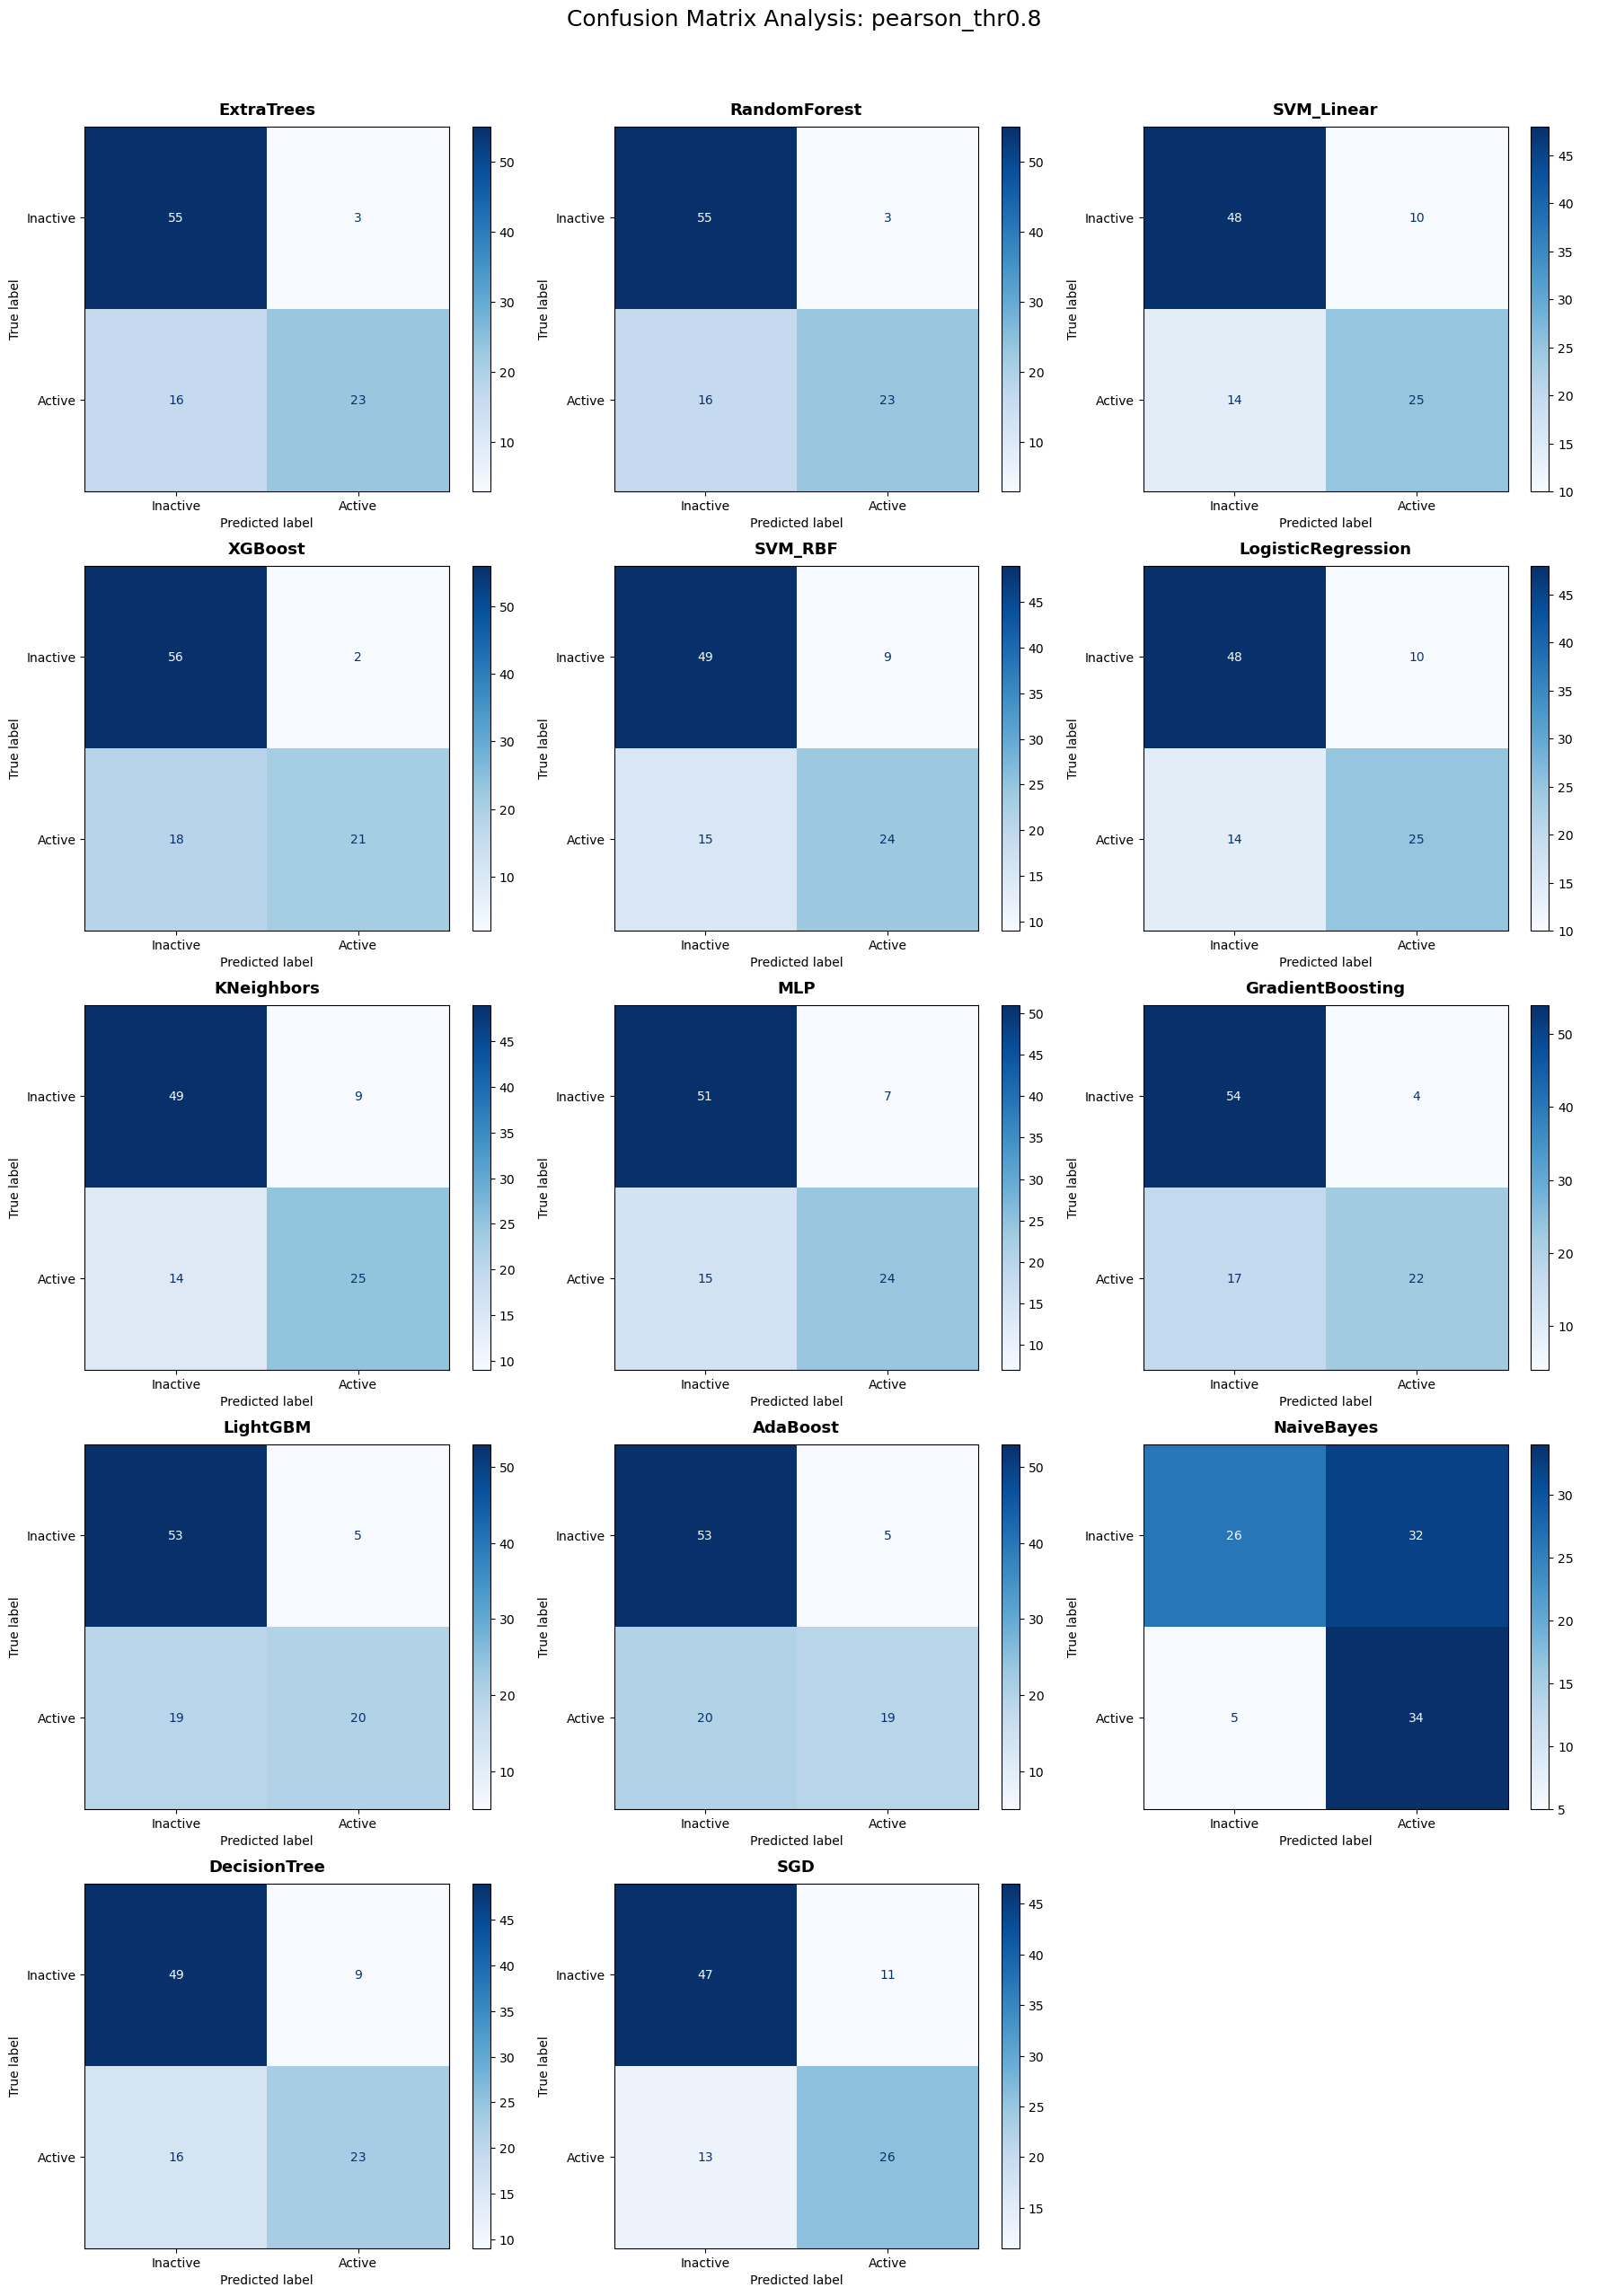

figuras/mordred/paso7_confusion_pearson_thr0.8_mordred.png guardado.


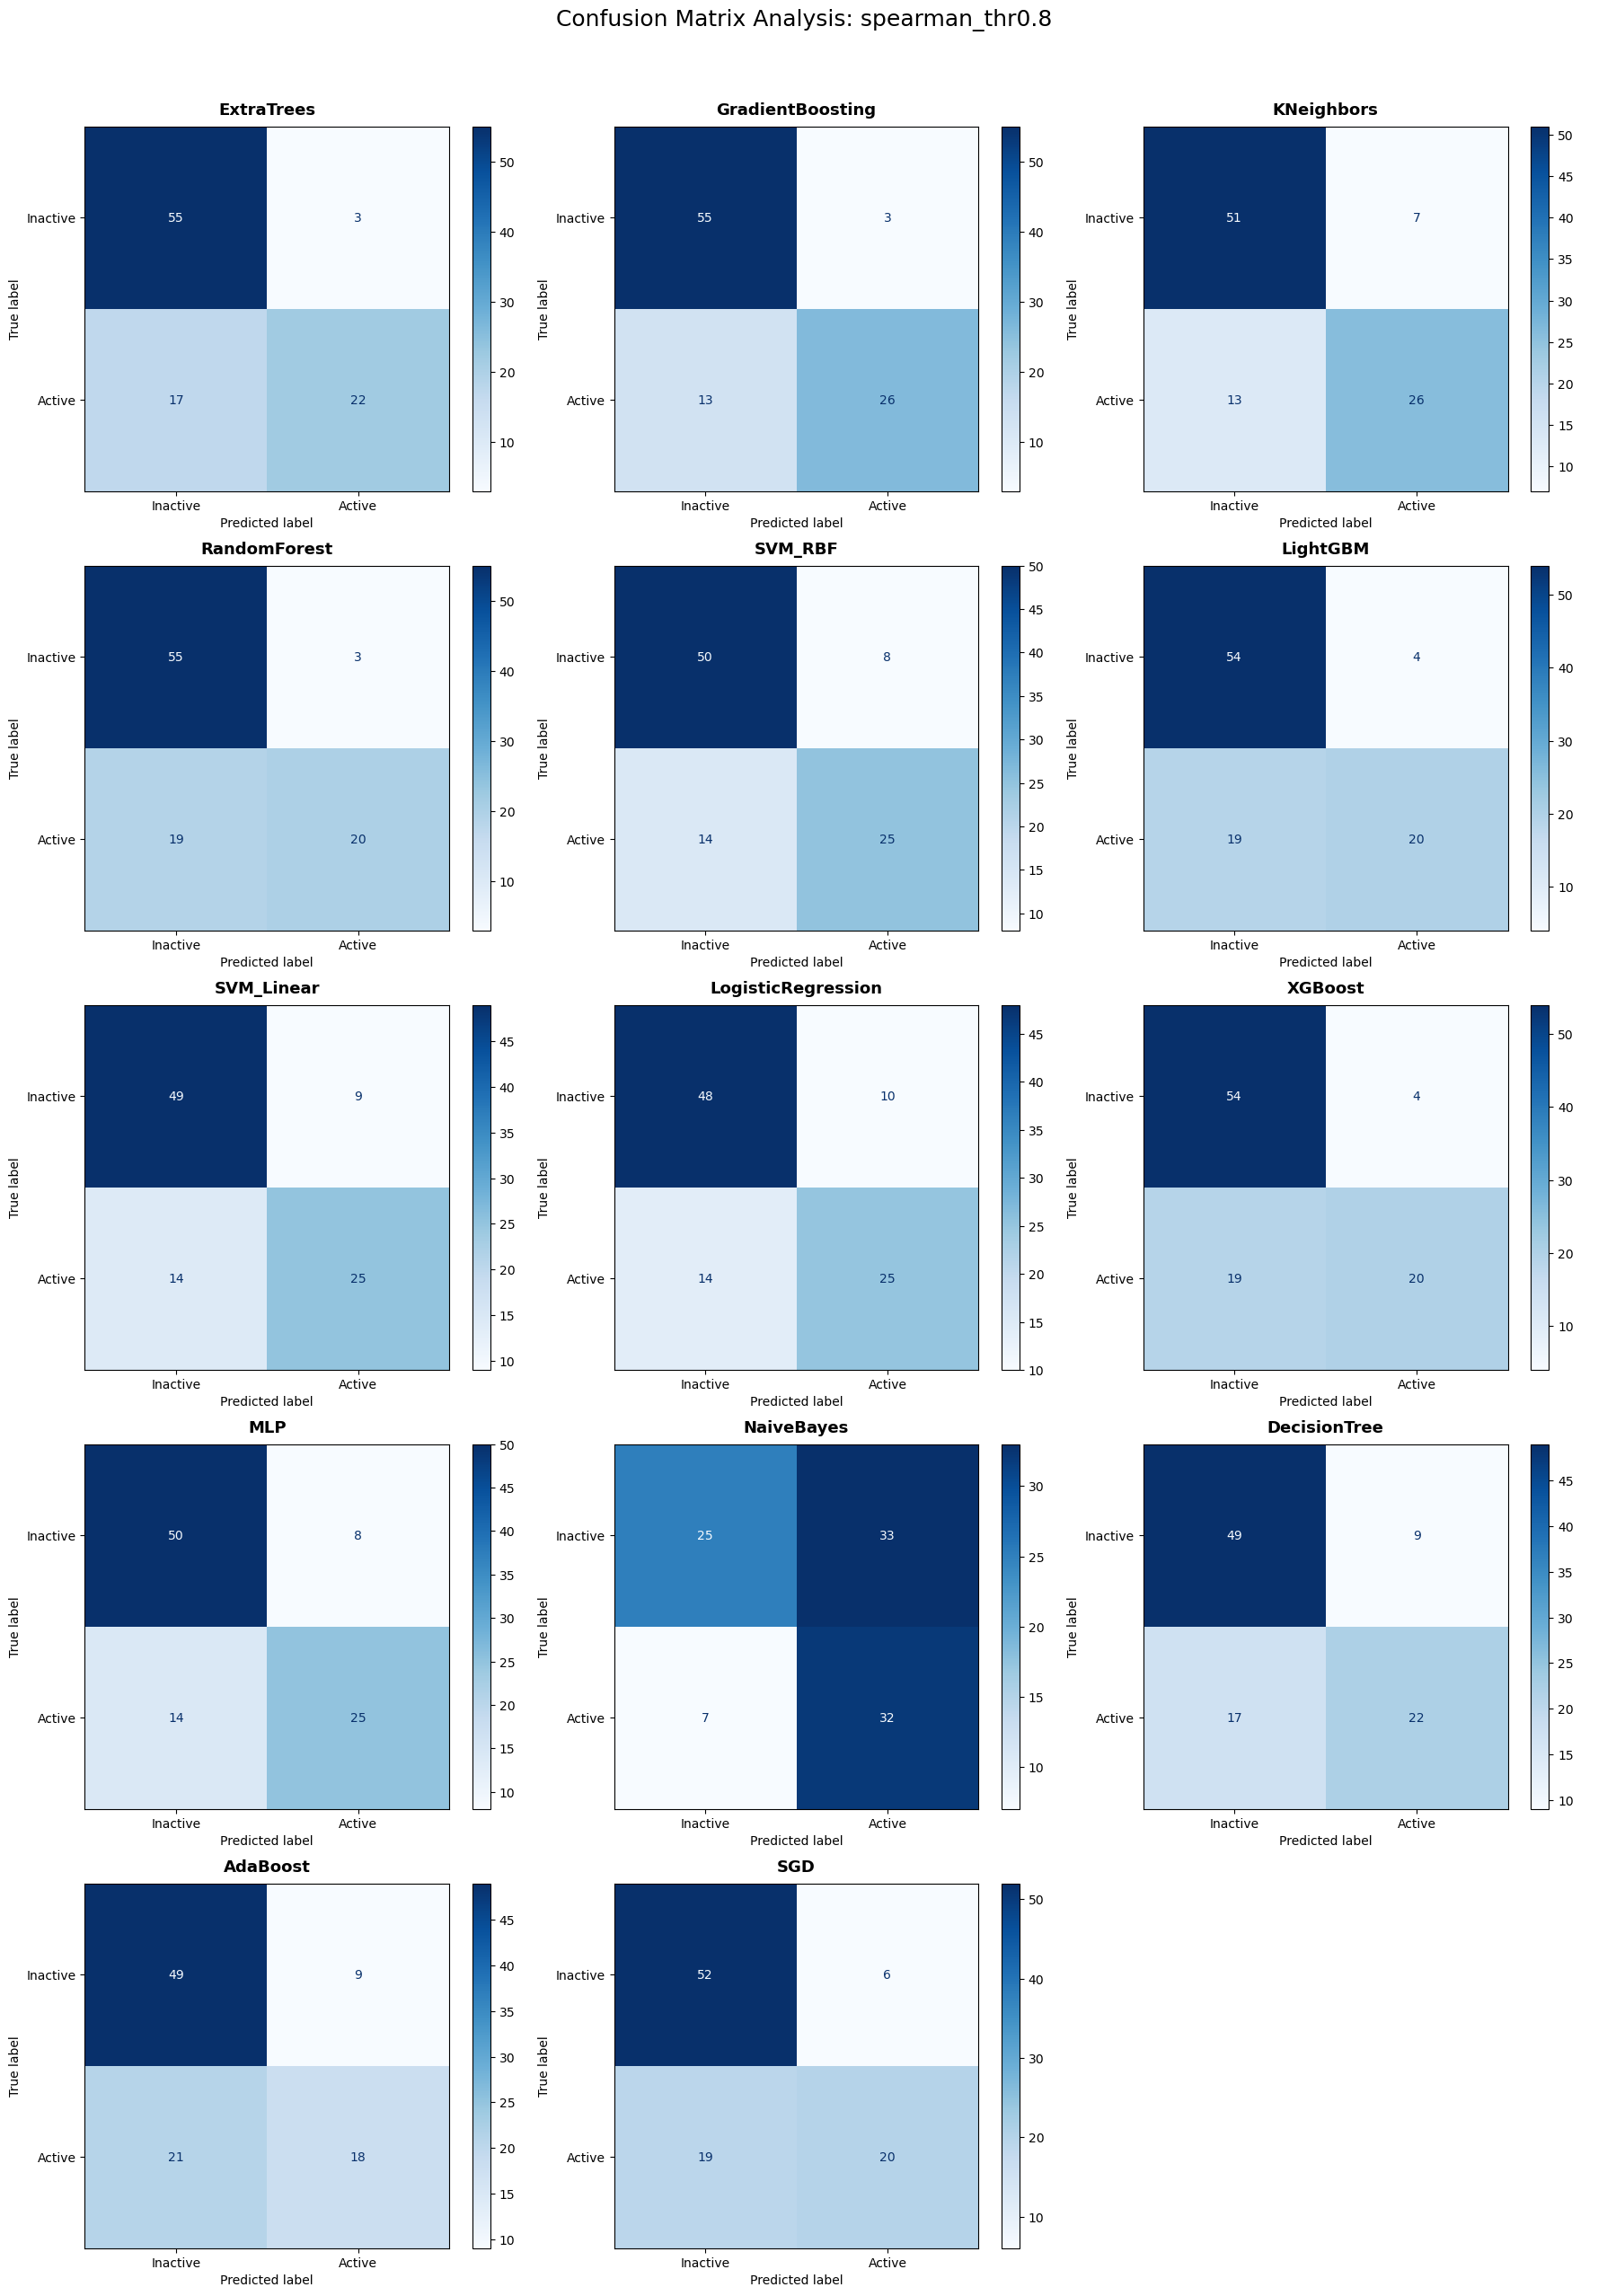

figuras/mordred/paso7_confusion_spearman_thr0.8_mordred.png guardado.


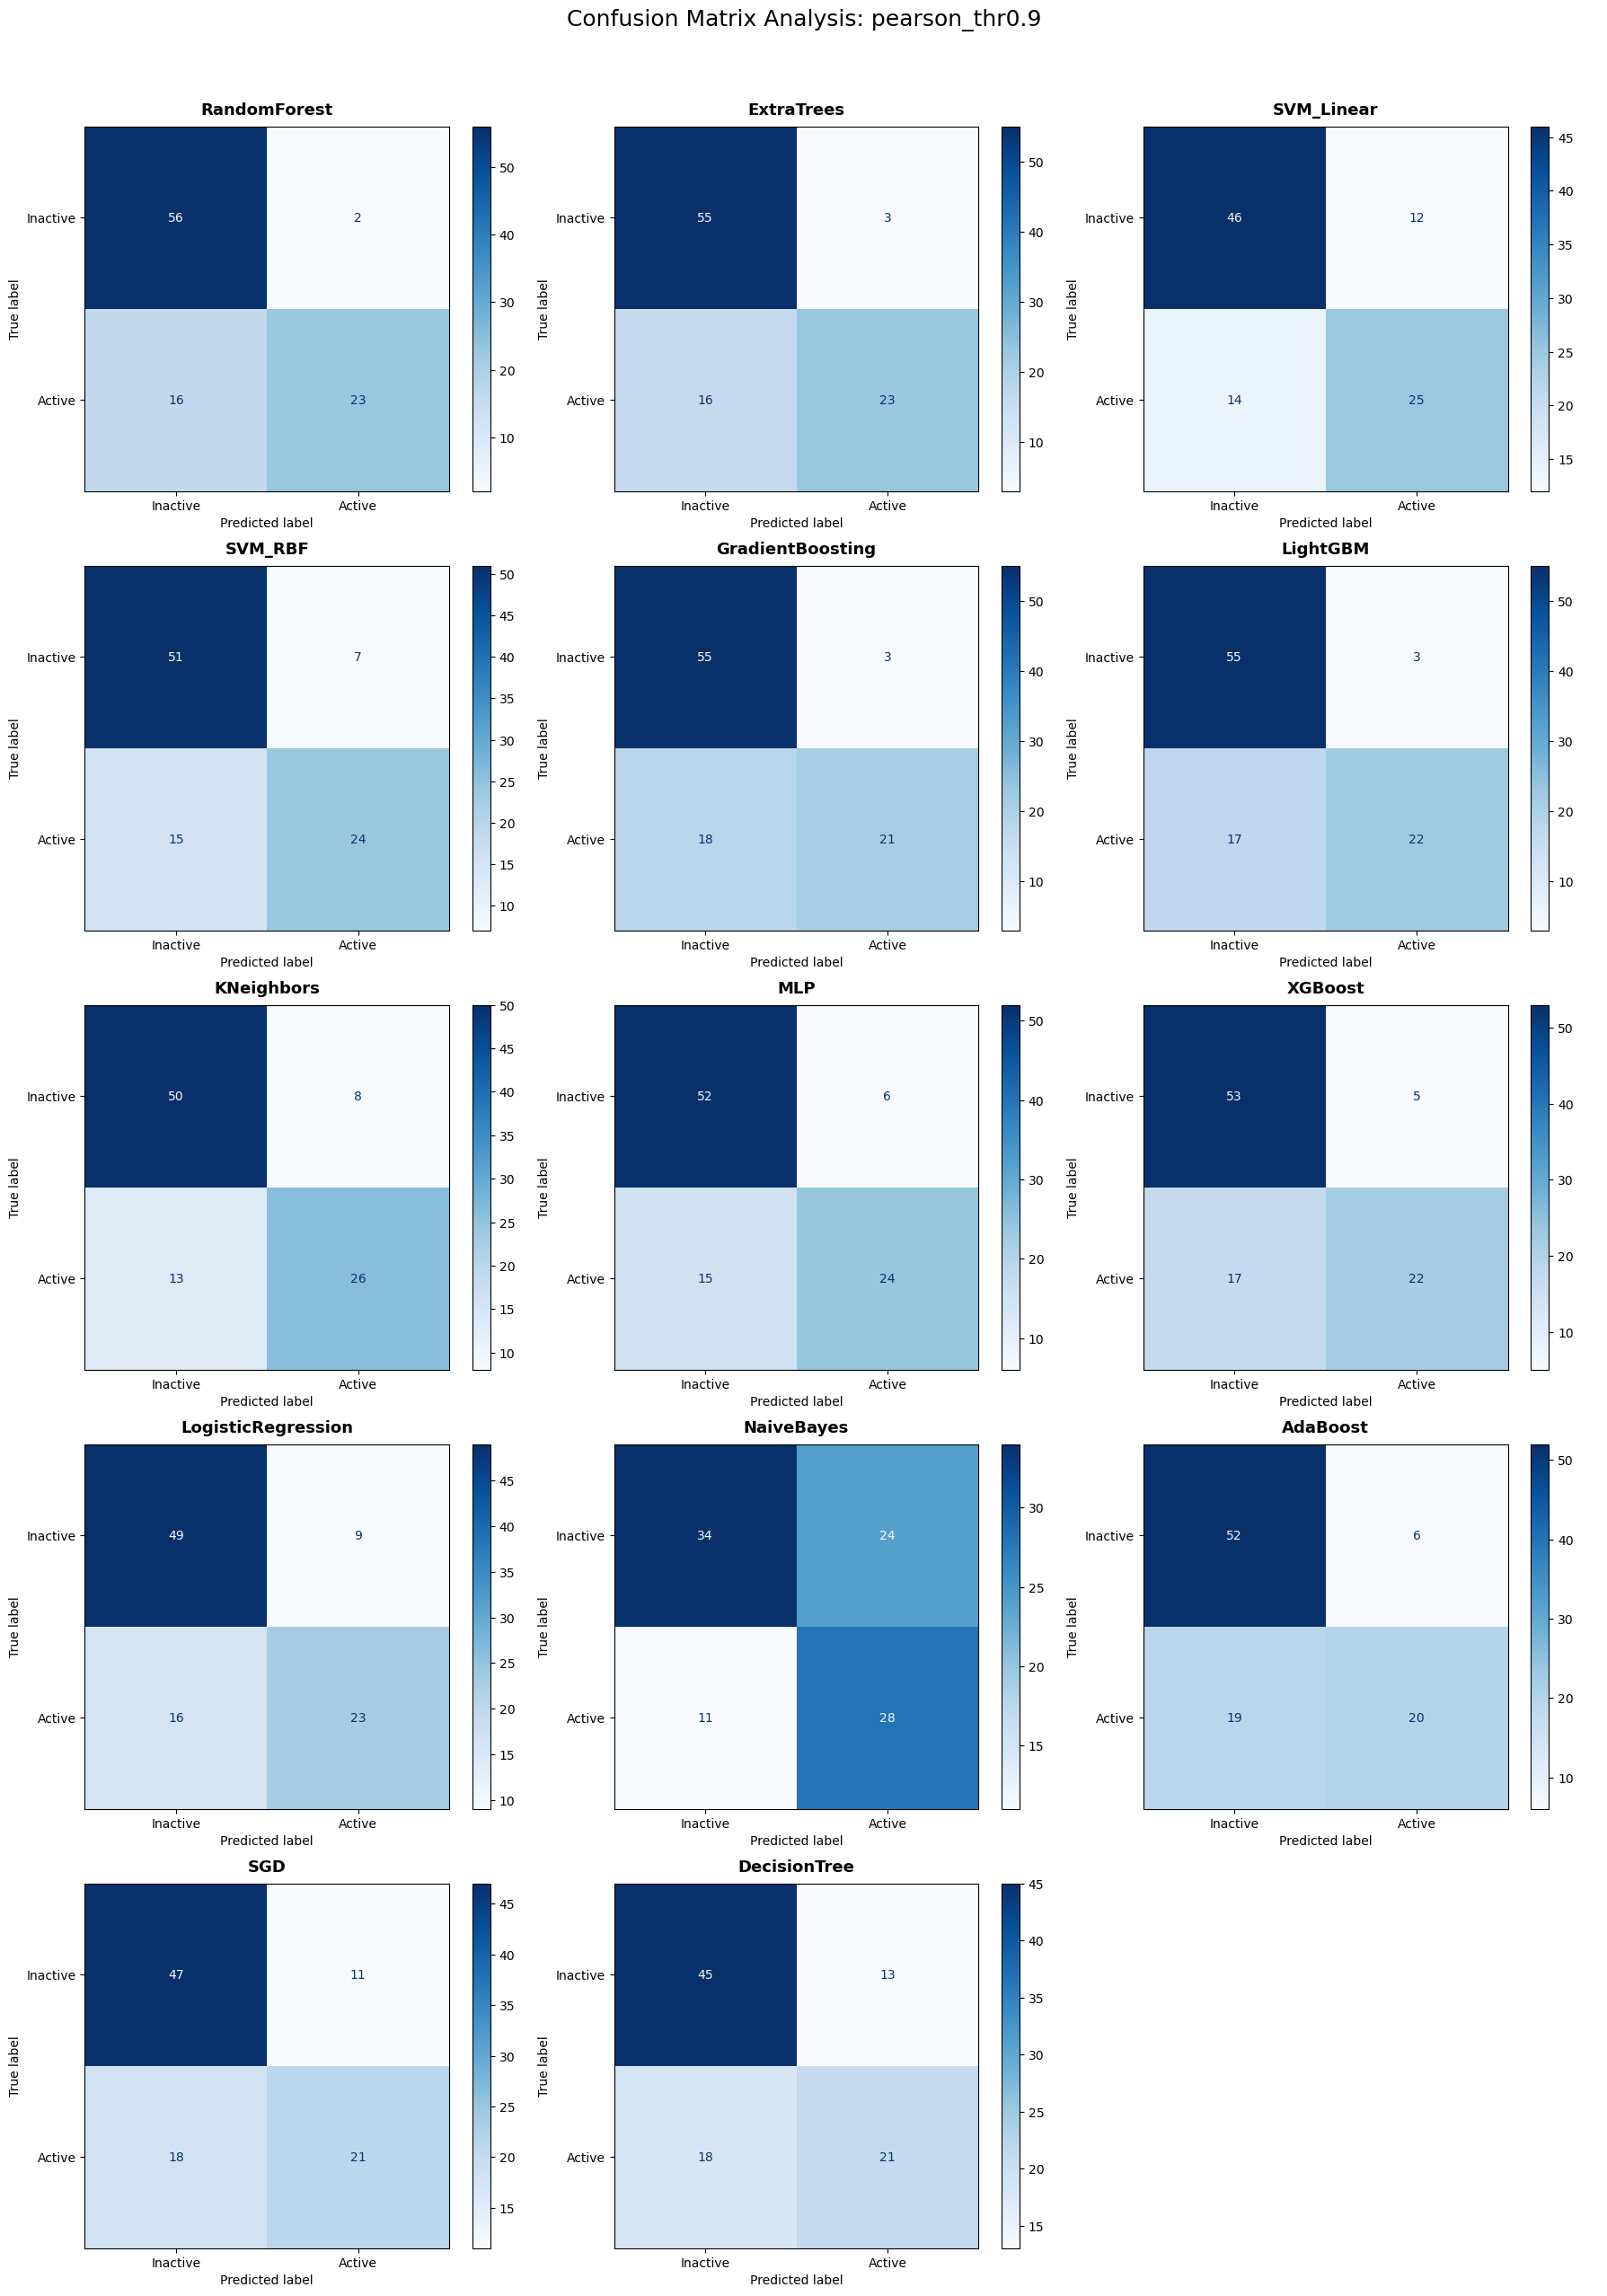

figuras/mordred/paso7_confusion_pearson_thr0.9_mordred.png guardado.


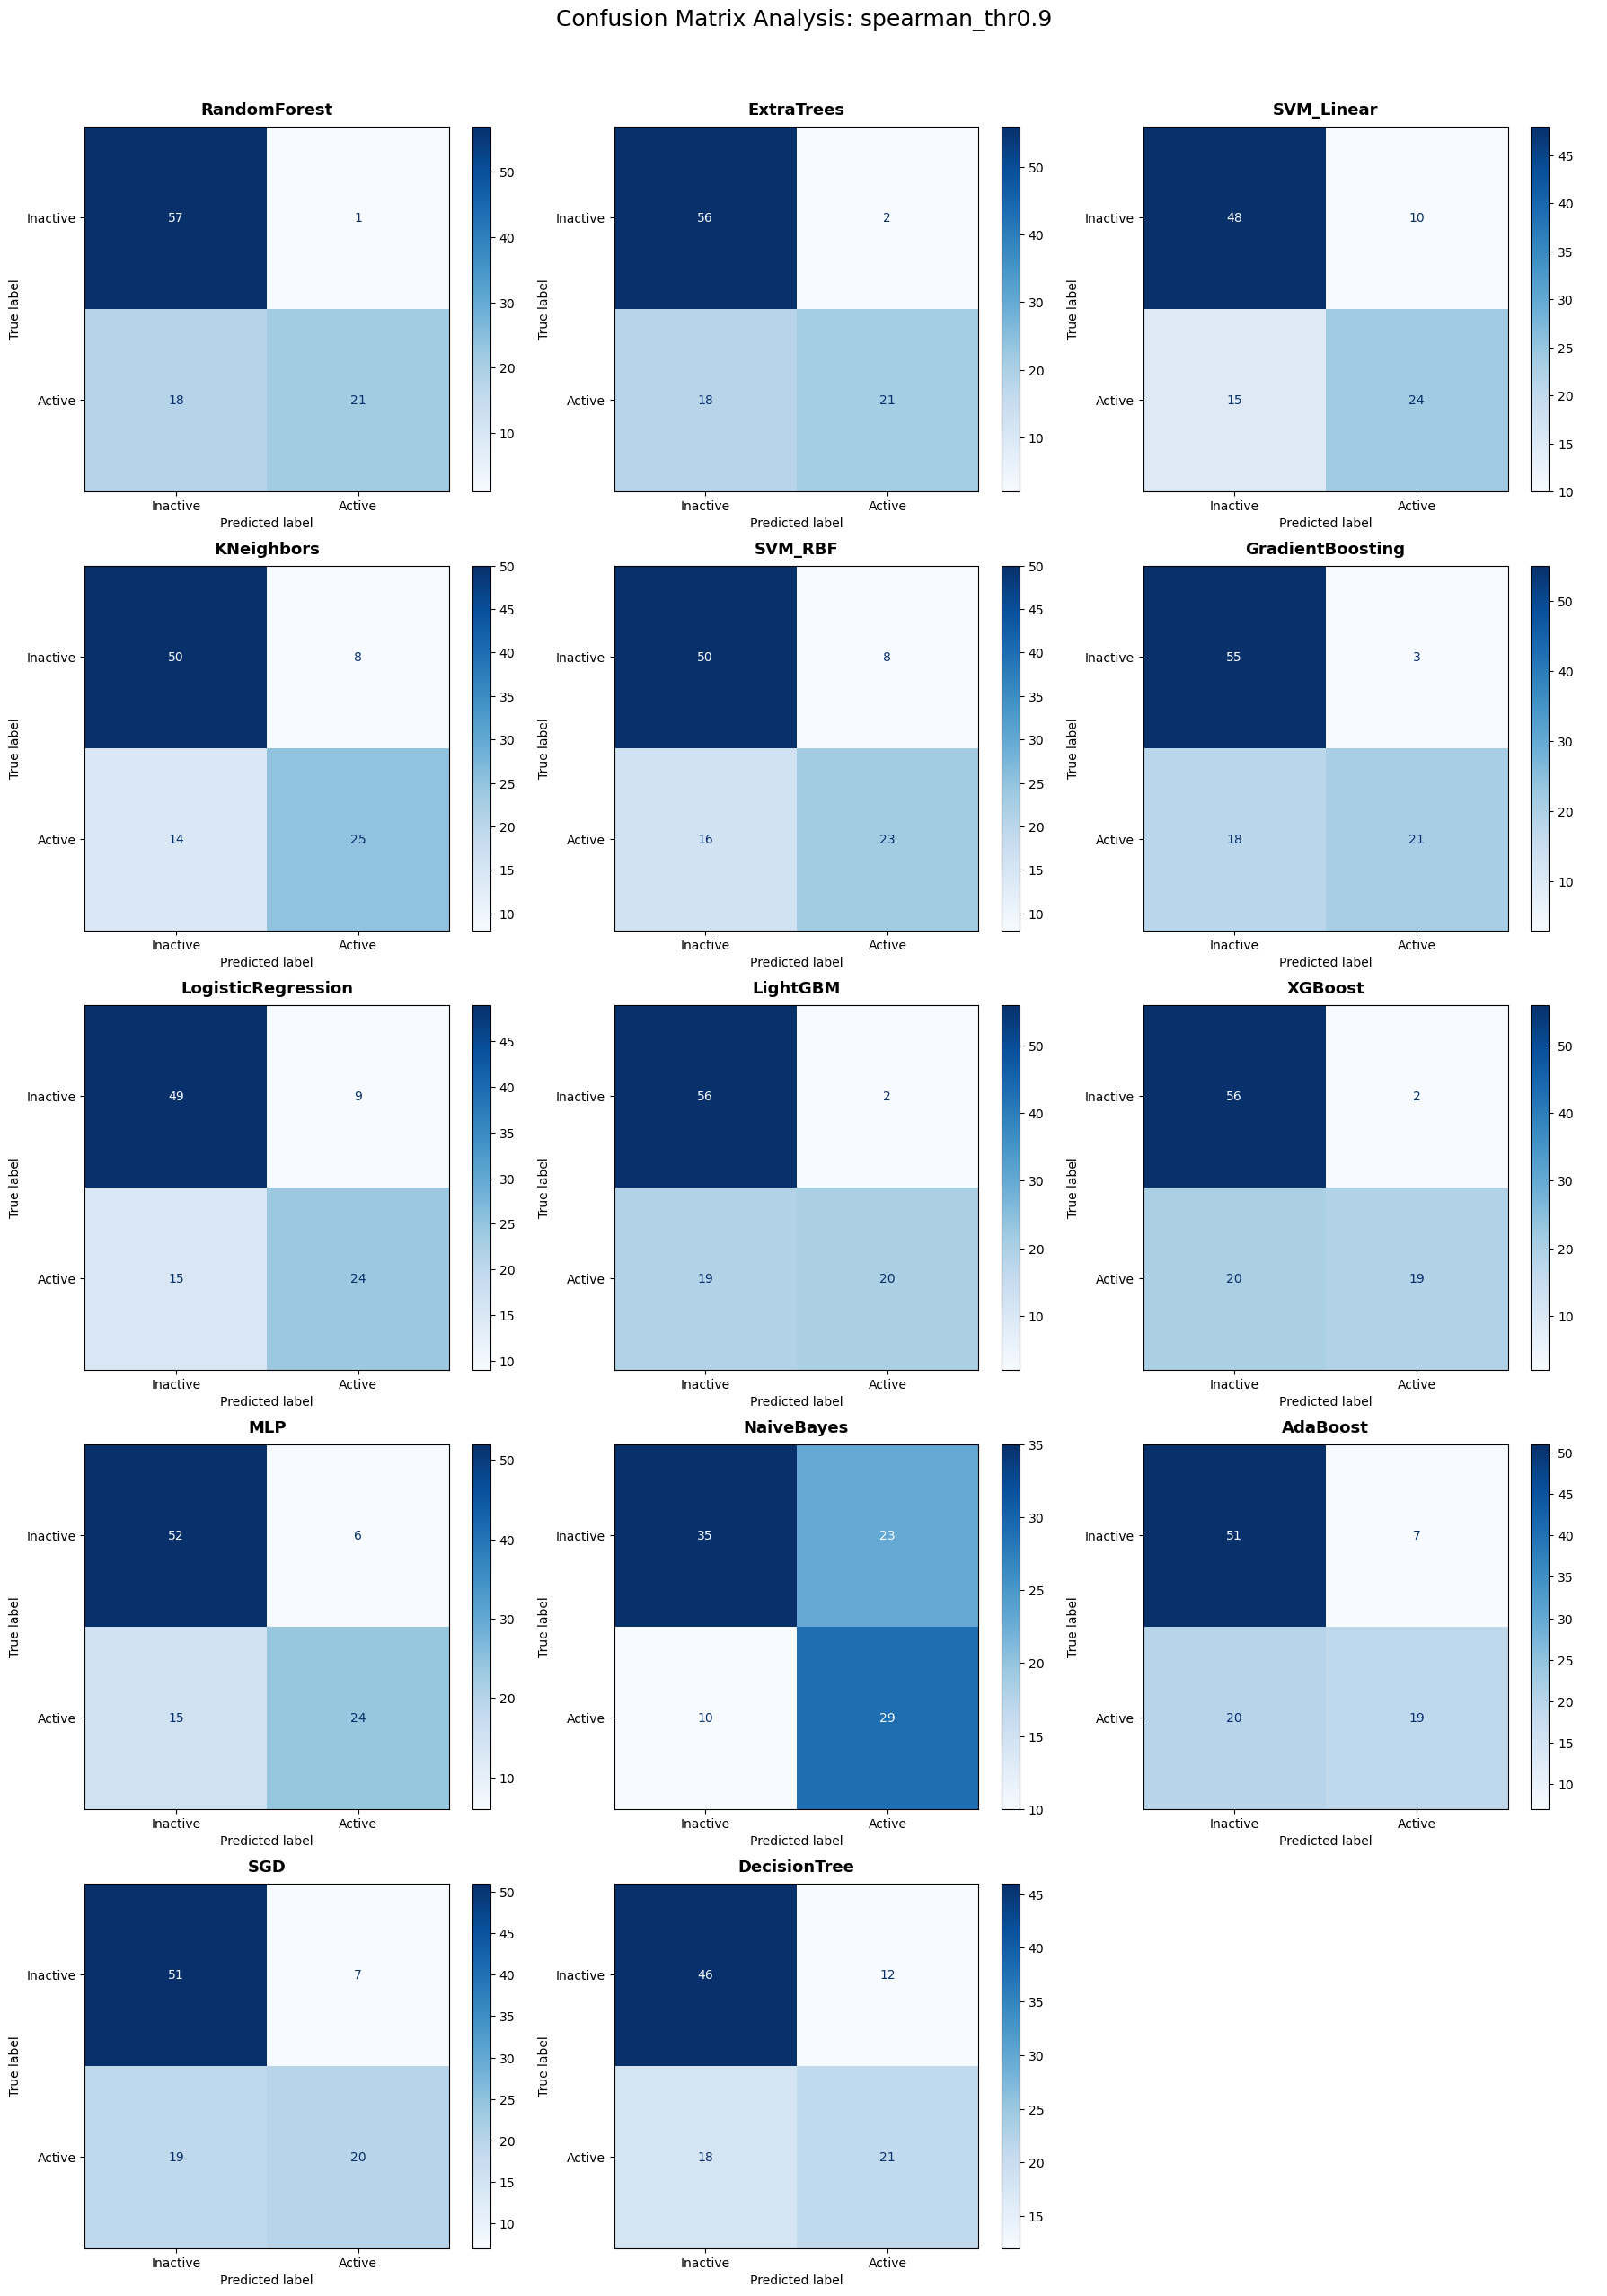

figuras/mordred/paso7_confusion_spearman_thr0.9_mordred.png guardado.


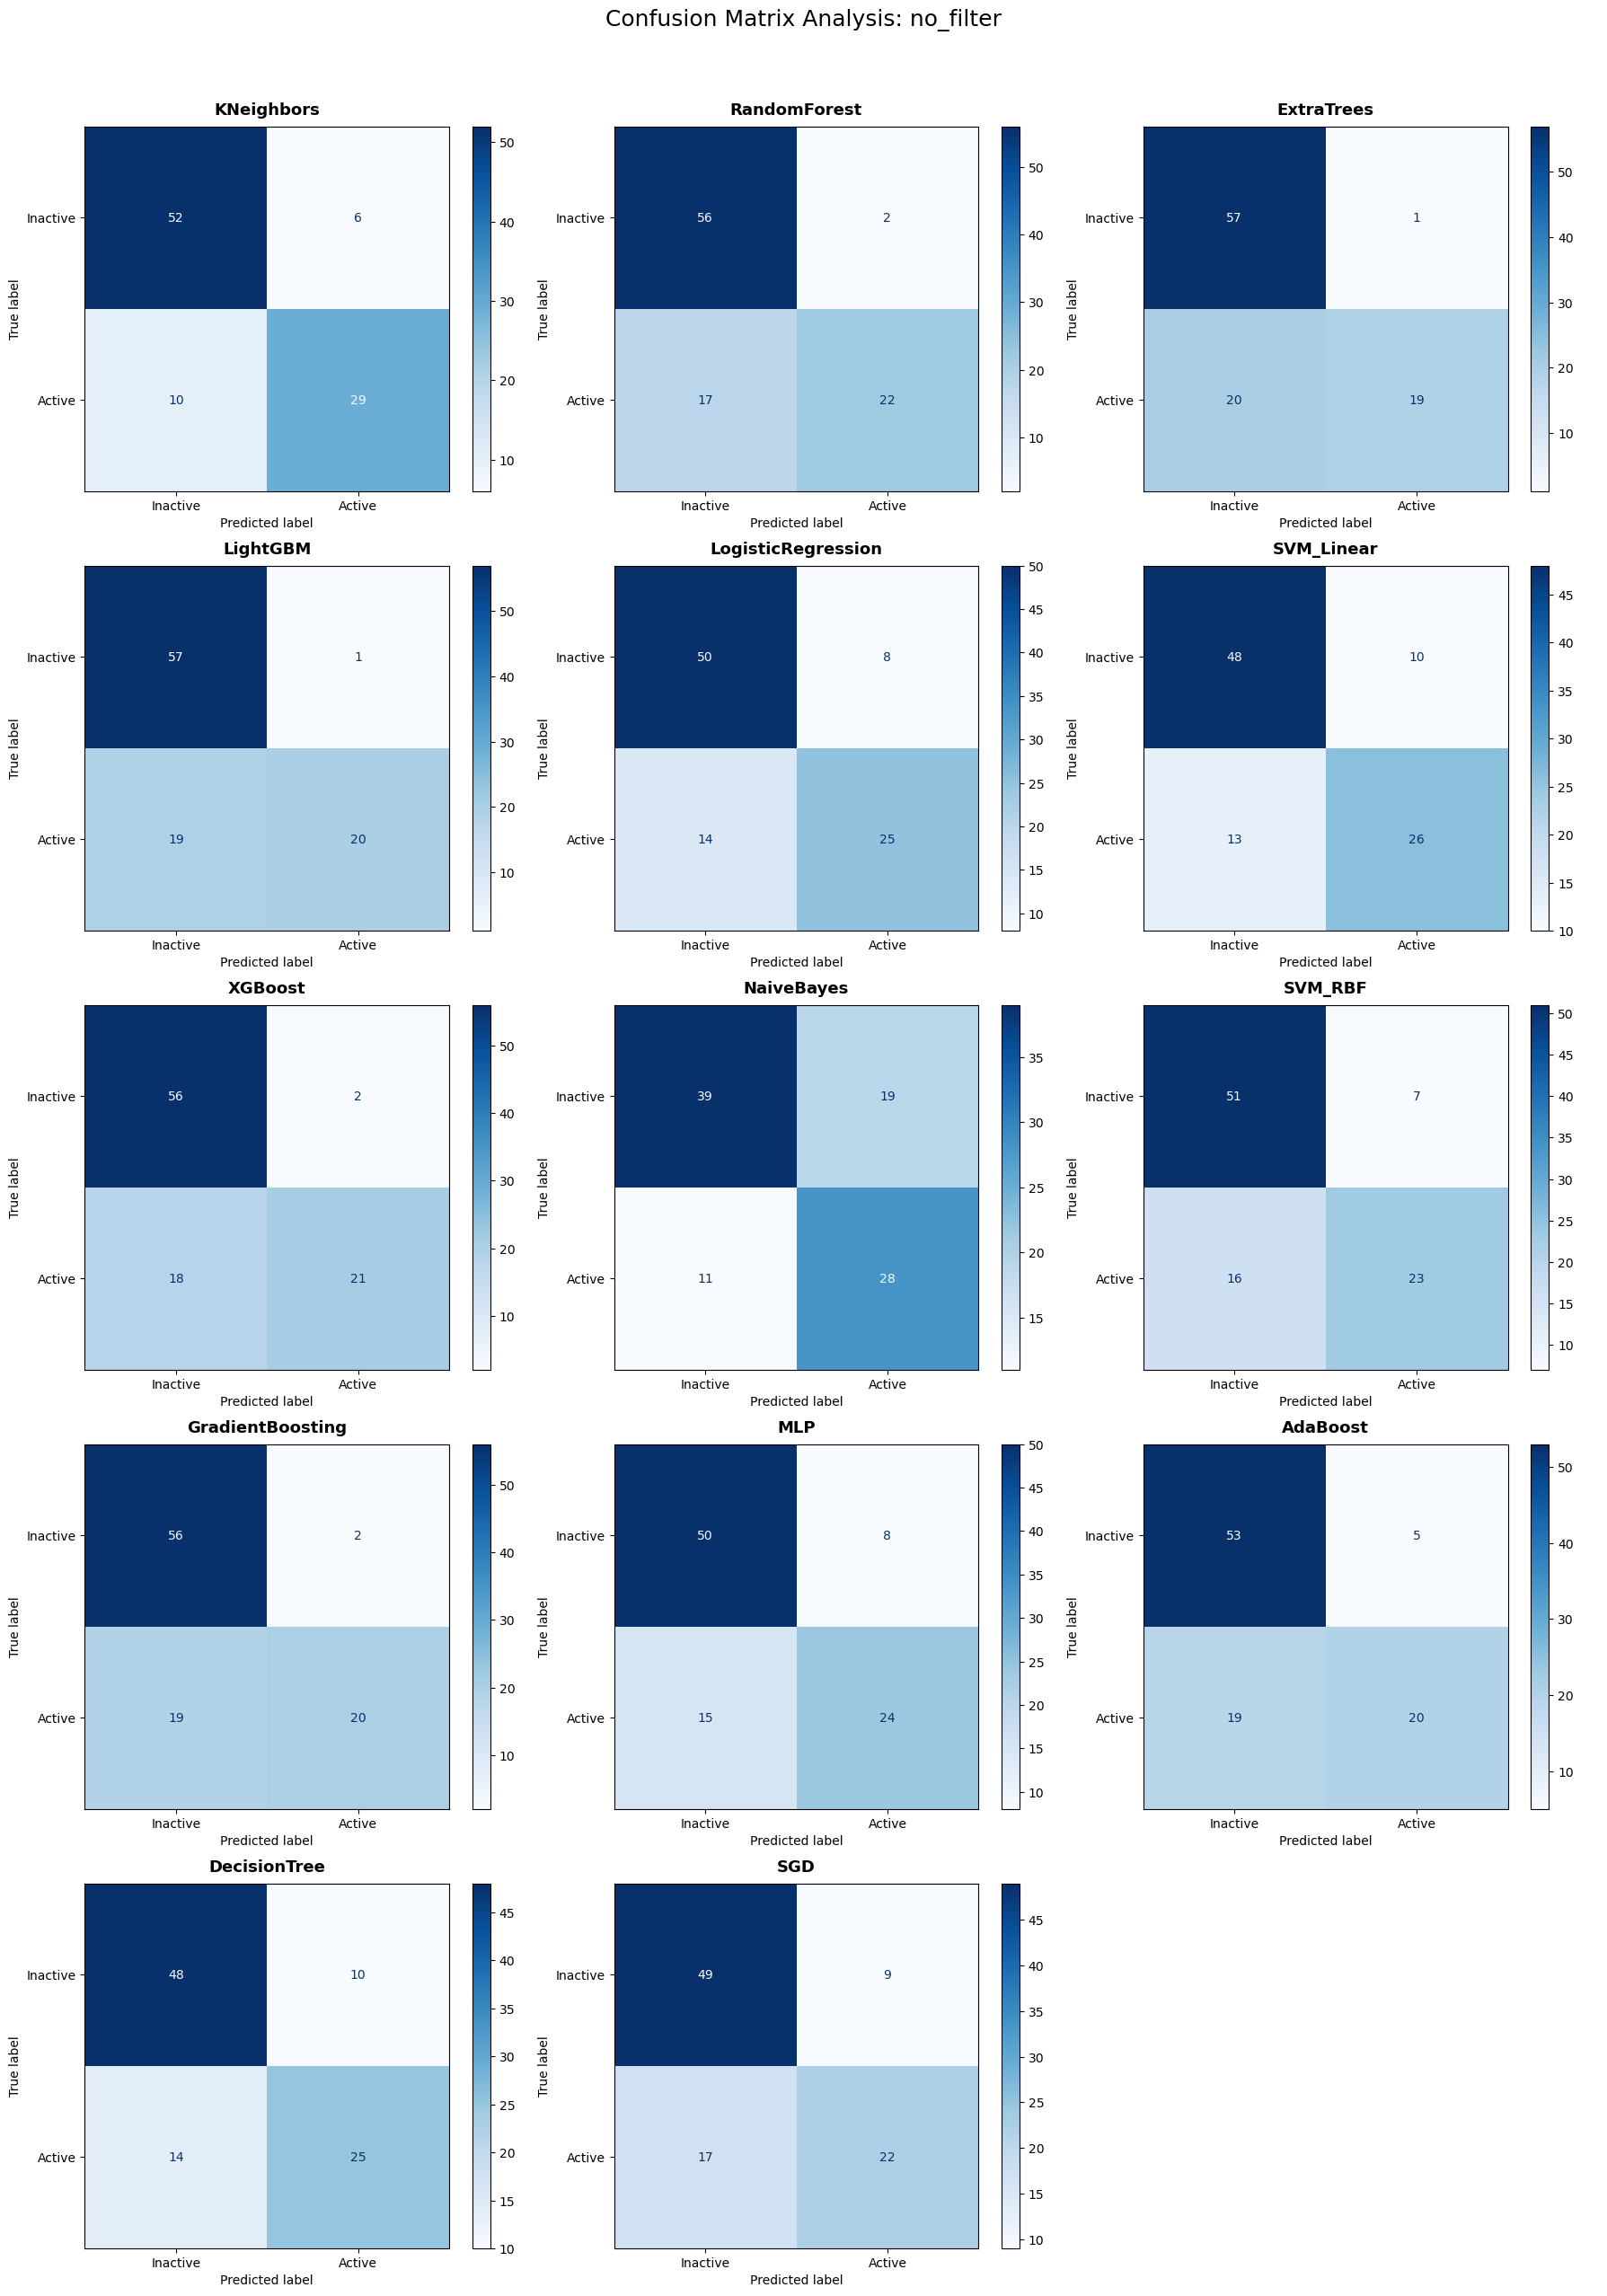

figuras/mordred/paso7_confusion_no_filter_mordred.png guardado.


In [22]:
def plot_matrices_by_feature_set(fs_name, results_df, estimators_dict, feature_sets_dict):
    fs_results = results_df[results_df["feature_set"] == fs_name]
    n_models = len(fs_results)
    if n_models == 0:
        return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = np.array(axes).reshape(-1)
    for i, (_, row) in enumerate(fs_results.iterrows()):
        model_name = row['model']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols_local = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols_local])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactive", "Active"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=13, pad=10, fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Confusion Matrix Analysis: {fs_name}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURAS}/paso7_confusion_{fs_name}_mordred.png', dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{FIGURAS}/paso7_confusion_{fs_name}_mordred.png guardado.")

# Una figura por cada uno de los 7 feature sets (pearson/spearman x 0.7/0.8/0.9, + no_filter)
for fs_name in feature_sets.keys():
    plot_matrices_by_feature_set(fs_name, df_results, best_estimators, feature_sets)


## 3.3 Realización de las curvas ROC

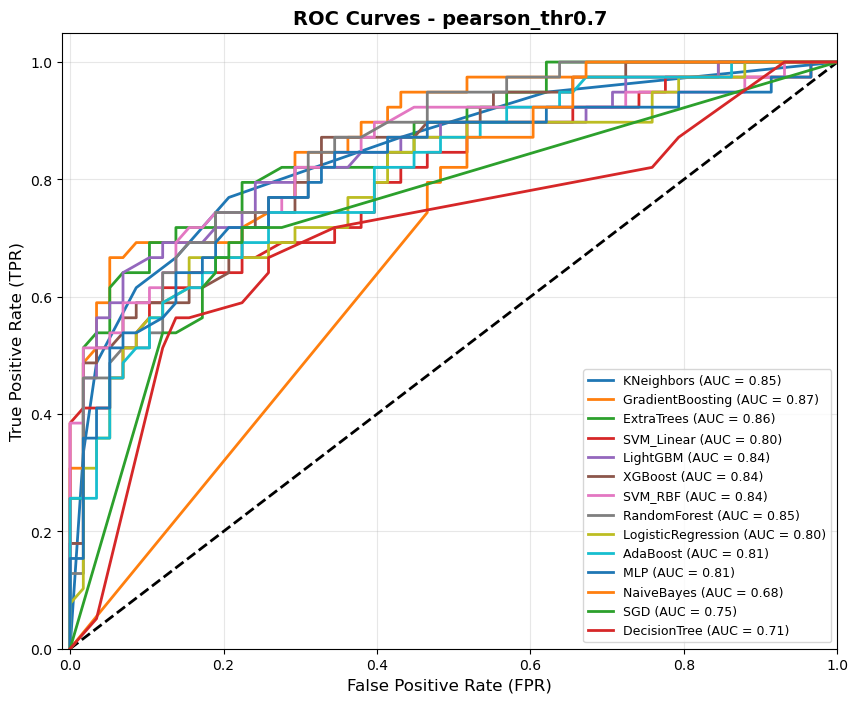

figuras/mordred/paso7_roc_comparison_pearson_thr0.7_mordred.png guardado.


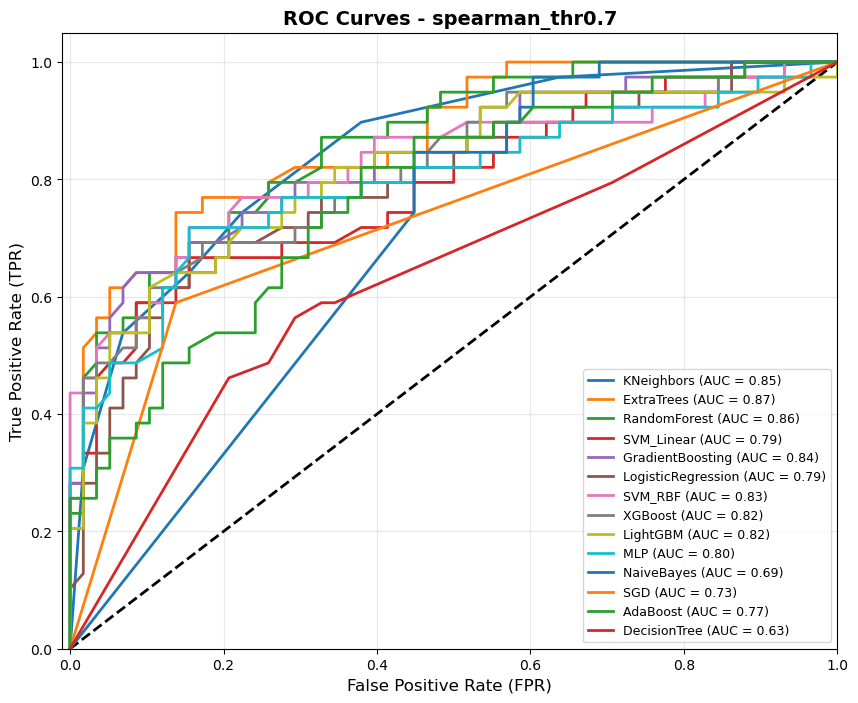

figuras/mordred/paso7_roc_comparison_spearman_thr0.7_mordred.png guardado.


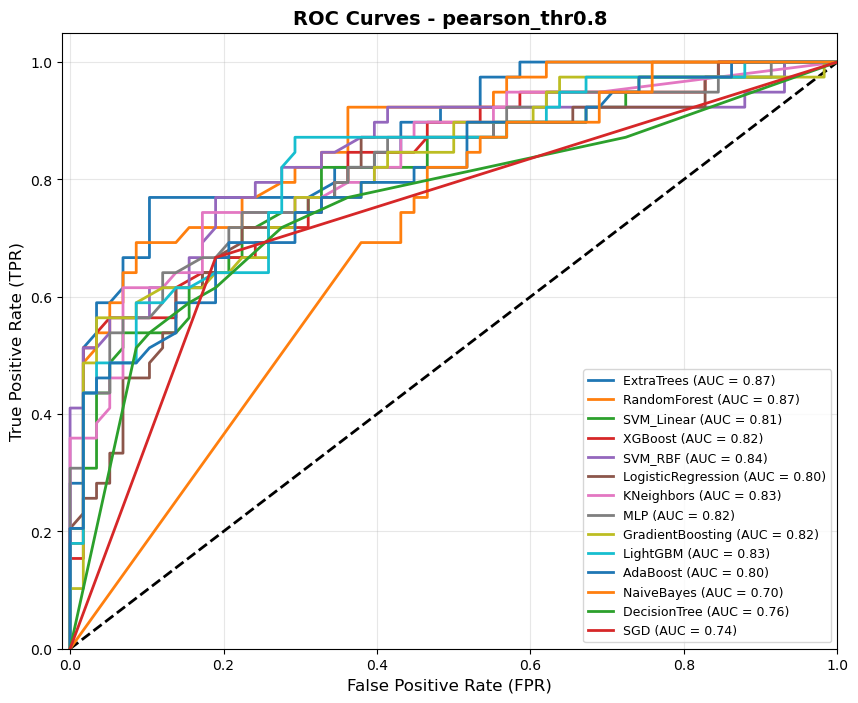

figuras/mordred/paso7_roc_comparison_pearson_thr0.8_mordred.png guardado.


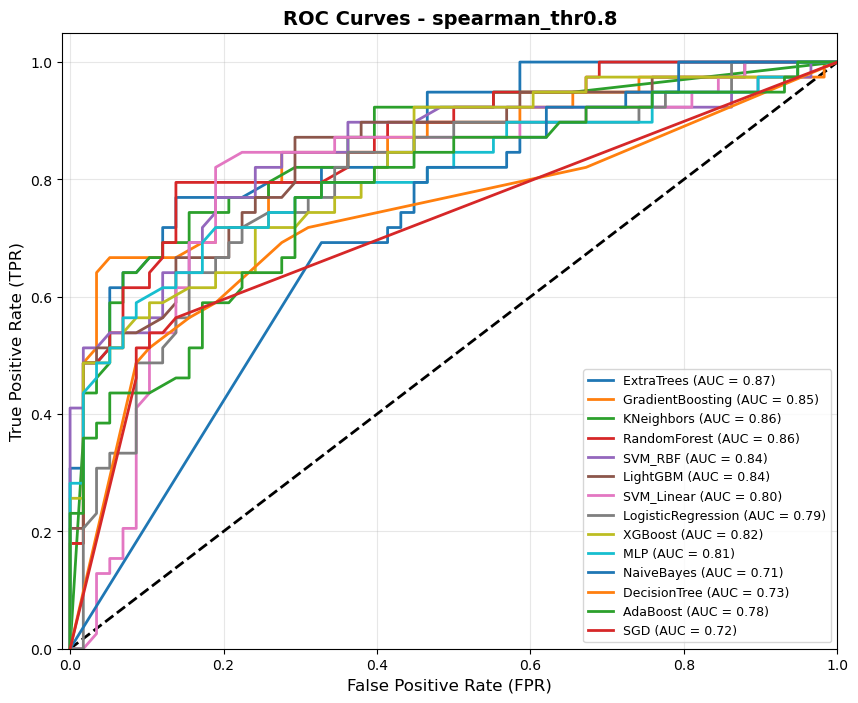

figuras/mordred/paso7_roc_comparison_spearman_thr0.8_mordred.png guardado.


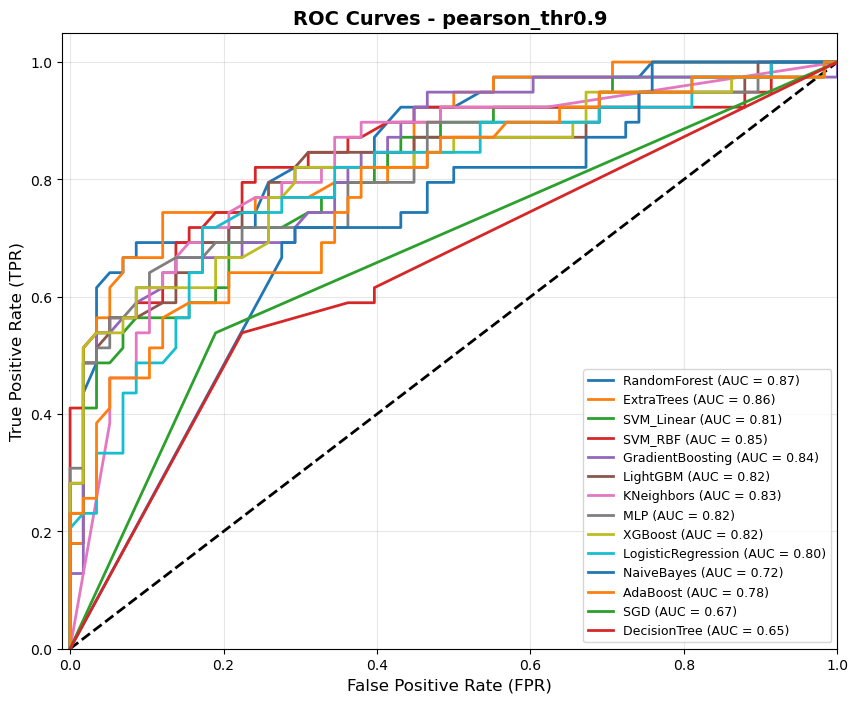

figuras/mordred/paso7_roc_comparison_pearson_thr0.9_mordred.png guardado.


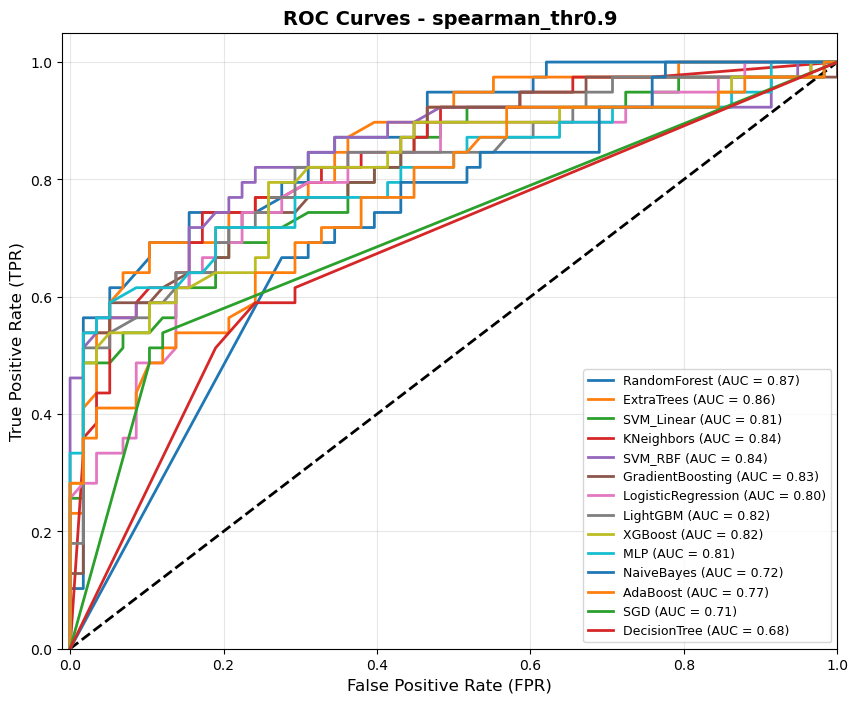

figuras/mordred/paso7_roc_comparison_spearman_thr0.9_mordred.png guardado.


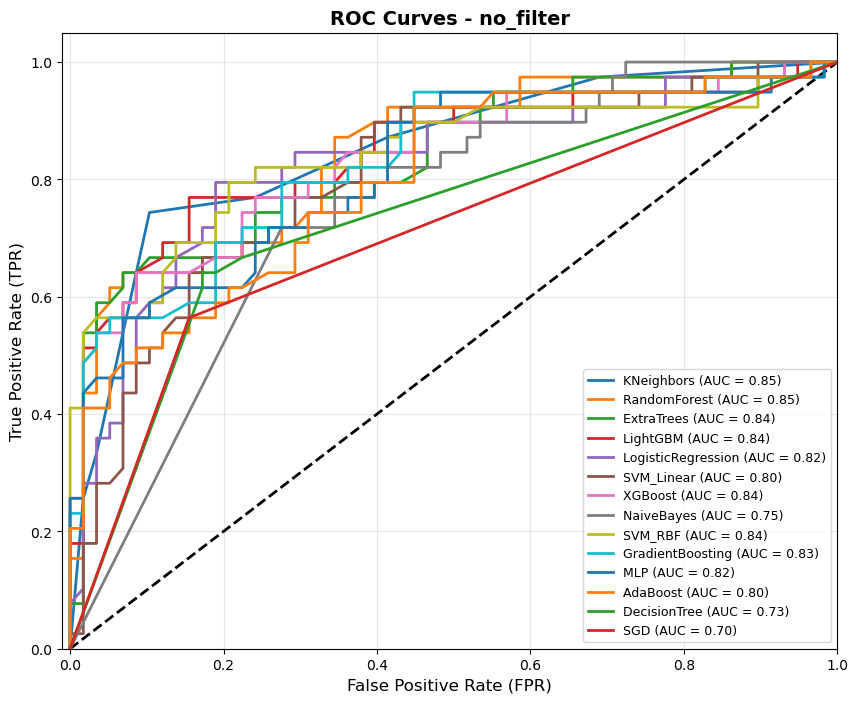

figuras/mordred/paso7_roc_comparison_no_filter_mordred.png guardado.


In [13]:
def plot_roc_curves_by_feature_set(fs_name, results_df, estimators_dict, feature_sets_dict):
    fs_results = results_df[results_df["feature_set"] == fs_name]
    if len(fs_results) == 0:
        return
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    for _, row in fs_results.iterrows():
        model_name = row['model']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols_local = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols_local])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols_local])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'ROC Curves - {fs_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.savefig(f'{FIGURAS}/paso7_roc_comparison_{fs_name}_mordred.png', dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{FIGURAS}/paso7_roc_comparison_{fs_name}_mordred.png guardado.")

# Una figura por cada uno de los 7 feature sets
for fs_name in feature_sets.keys():
    plot_roc_curves_by_feature_set(fs_name, df_results, best_estimators, feature_sets)


## 3.4 Realización del overfit gap

In [23]:
pivot_gap = df_results.pivot_table(
    index="model", columns="feature_set",
    values="overfit_gap", aggfunc="min"
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_gap, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Overfit Gap (acc_train − acc_test)")
plt.tight_layout()
plt.savefig(f'{FIGURAS}/paso7_overfit_heatmap_mordred.png',
            dpi=150, bbox_inches="tight")
plt.close()

## 3.5 Ranking de los modelos

In [37]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])
 
print(f"\n{'='*60}")
print(f"MEJOR MODELO : {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass
 
pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv(f'{OUTPUT_DIR_ML}/paso7_report_mejor_modelo.csv')
 
print(f"\n✅ Gráficos y reportes del paso 7 guardados.")


MEJOR MODELO : KNeighbors
Feature set  : pearson_thr0.7 (317 descriptores)
              precision    recall  f1-score   support

    Inactivo       0.79      0.86      0.83        58
      Activo       0.76      0.67      0.71        39

    accuracy                           0.78        97
   macro avg       0.78      0.76      0.77        97
weighted avg       0.78      0.78      0.78        97

MCC = 0.5433
ROC-AUC = 0.8473

✅ Gráficos y reportes del paso 7 guardados.


# 4. Dominio de aplicabilidad - kNN 

TOP 3 MODELS SELECTED FOR THE APPLICABILITY DOMAIN   
           model    feature_set  n_features  cv_roc_auc_mean  roc_auc_test
      KNeighbors pearson_thr0.7         317         0.847184      0.847259
GradientBoosting pearson_thr0.7         317         0.865391      0.870911
      ExtraTrees pearson_thr0.7         317         0.867903      0.864279

Descriptors (k)         : 317
Train compounds (n)     : 373
kNN-AD threshold           : 14.9951

Train - mean distance (mean +/- std): 8.1954 +/- 3.3999
Test  - inside the AD    : 95 (97.9%)
Test  - outside the AD     : 2 (2.1%)


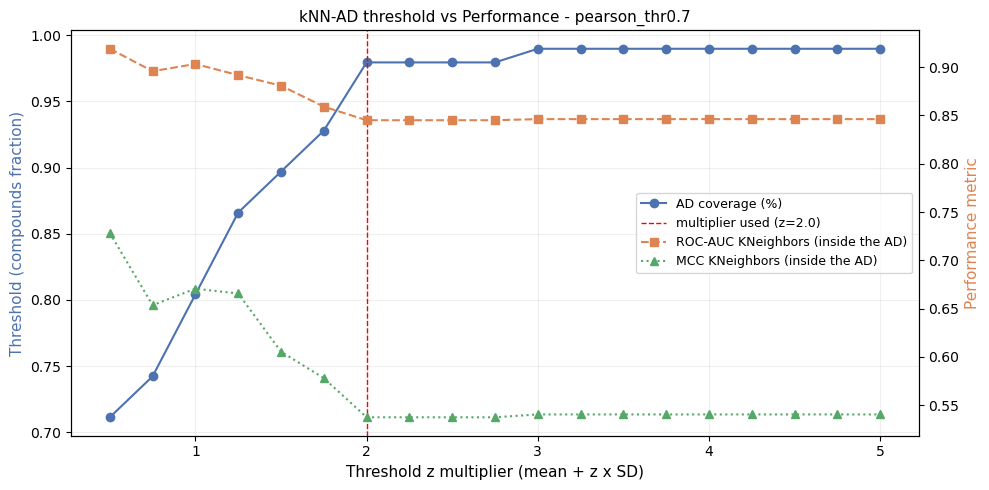

resultados dominio de aplicabilidad mordred/paso8_ad_coverage_pearson_thr0.7_mordred.png guardado.
split  in_AD
test   0          2
       1         95
train  1        373
resultados dominio de aplicabilidad mordred/paso8_knnAD_pearson_thr0.7_mordred.csv guardado.

[1/3] MODELO: KNeighbors  |  Feature set: pearson_thr0.7


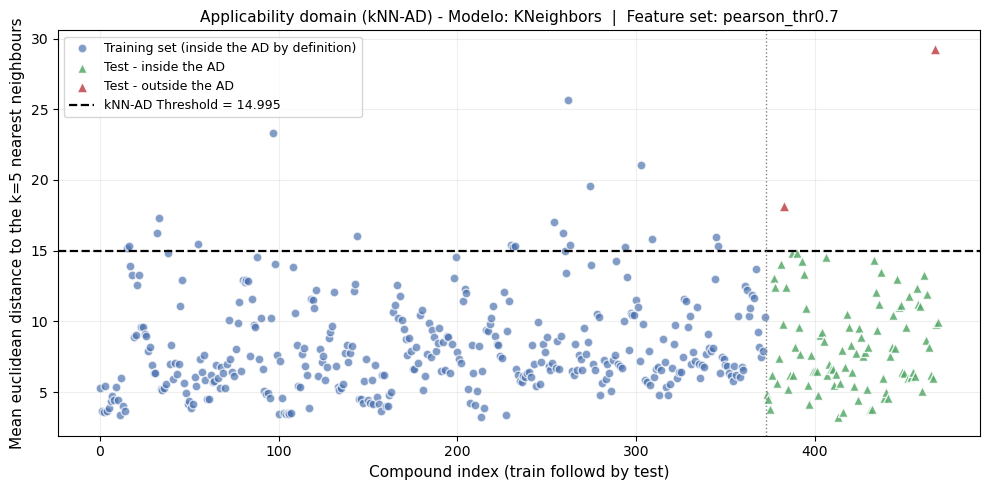

resultados dominio de aplicabilidad mordred/paso8_knnAD_scatter_top1_KNeighbors_mordred.png guardado.

-- Test completed (n=97) --
  Accuracy  : 0.7835
  F1        : 0.7123
  MCC       : 0.5433
  ROC-AUC   : 0.8473

-- Test inside the AD (n=95) --
  Accuracy  : 0.7789
  F1        : 0.7123
  MCC       : 0.5375
  ROC-AUC   : 0.8450

-- Test outside the AD (n=2) --
  Accuracy  : 1.0000
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top1_KNeighbors_mordred.csv guardado.

[2/3] MODELO: GradientBoosting  |  Feature set: pearson_thr0.7


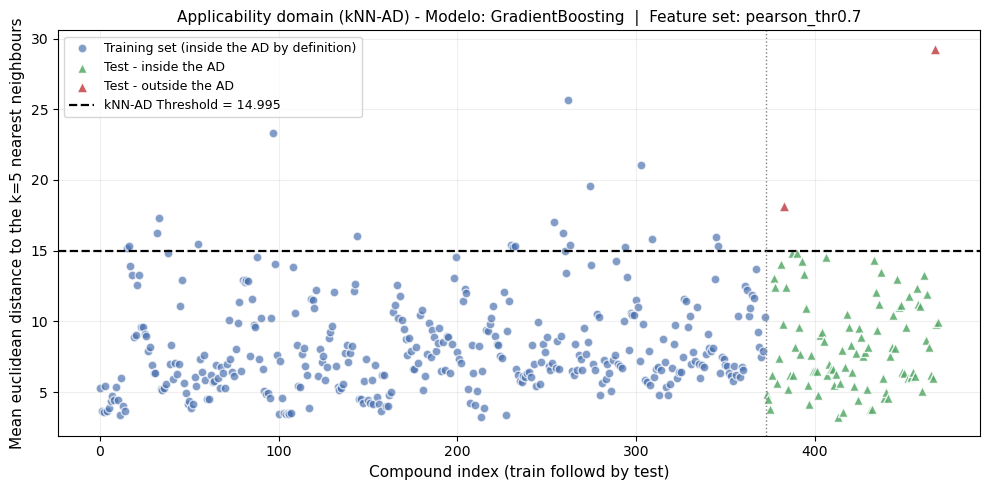

resultados dominio de aplicabilidad mordred/paso8_knnAD_scatter_top2_GradientBoosting_mordred.png guardado.

-- Test completed (n=97) --
  Accuracy  : 0.8247
  F1        : 0.7463
  MCC       : 0.6376
  ROC-AUC   : 0.8709

-- Test inside the AD (n=95) --
  Accuracy  : 0.8211
  F1        : 0.7463
  MCC       : 0.6338
  ROC-AUC   : 0.8700

-- Test outside the AD (n=2) --
  Accuracy  : 1.0000
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top2_GradientBoosting_mordred.csv guardado.

[3/3] MODELO: ExtraTrees  |  Feature set: pearson_thr0.7


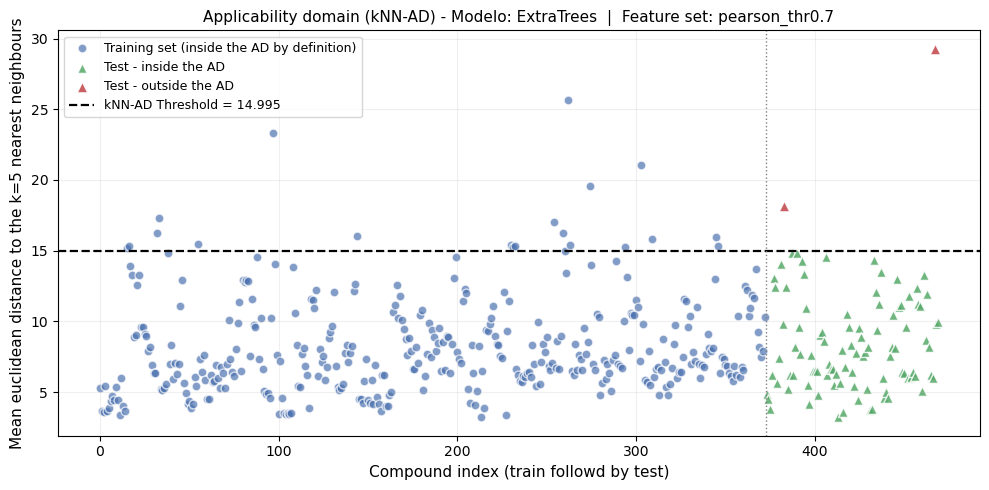

resultados dominio de aplicabilidad mordred/paso8_knnAD_scatter_top3_ExtraTrees_mordred.png guardado.

-- Test completed (n=97) --
  Accuracy  : 0.8041
  F1        : 0.7077
  MCC       : 0.5956
  ROC-AUC   : 0.8643

-- Test inside the AD (n=95) --
  Accuracy  : 0.8000
  F1        : 0.7077
  MCC       : 0.5916
  ROC-AUC   : 0.8645

-- Test outside the AD (n=2) --
  Accuracy  : 1.0000
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top3_ExtraTrees_mordred.csv guardado.

RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)
 rank            model    feature_set  roc_auc_all  roc_auc_in_AD  mcc_all  mcc_in_AD
    1       KNeighbors pearson_thr0.7       0.8473         0.8450   0.5433     0.5375
    2 GradientBoosting pearson_thr0.7       0.8709         0.8700   0.6376     0.6338
    3       ExtraTrees pearson_thr0.7       0.8643         0.8645   0.5956     0.5916

paraso8_summary_top3_mordred.csv guardado.


In [ ]:
# Una molecula se considera DENTRO del dominio si esta "cerca" (en el espacio
# de descriptores estandarizado) de las moleculas del training set. Este
# metodo es agnostico al algoritmo de ML: depende solo del feature set, no
# del clasificador.
#
# Algoritmo (kNN-AD):
#   1. Estandarizar los descriptores con la media/SD del TRAIN set.
#   2. Para cada compuesto de train, calcular la distancia euclidea media a
#      sus k=5 vecinos mas cercanos DENTRO DEL PROPIO TRAIN (excluyendo el
#      compuesto consigo mismo, para no inflar artificialmente la distancia
#      media con un cero).
#   3. Umbral = media + 2 x desviacion estandar de esas distancias en train.
#   4. Para cada compuesto de test, calcular su distancia media a los k=5
#      vecinos mas cercanos DEL TRAIN. Si esa distancia < umbral, esta
#      dentro del AD.

def metrics_summary(y_true, y_pred, y_prob, label):
    print(f"\n-- {label} (n={len(y_true)}) --")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, y_pred):.4f}")
    if len(np.unique(y_true)) > 1:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'subset'  : label,
        'n'       : len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'mcc'     : matthews_corrcoef(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


def knn_ad(X_train: pd.DataFrame, X_test: pd.DataFrame, n_neighbors: int = 5, z: float = 2.0):
    scaler_ad = StandardScaler()
    X_train_ad = scaler_ad.fit_transform(X_train)
    X_test_ad  = scaler_ad.transform(X_test)

    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)  # +1 porque el propio punto sera su vecino 0 en train
    nn.fit(X_train_ad)

    # Distancias en TRAIN: se excluye la columna 0 (distancia a si mismo = 0)
    distances_train, _ = nn.kneighbors(X_train_ad)
    mean_dist_train = distances_train[:, 1:].mean(axis=1)

    threshold = mean_dist_train.mean() + z * mean_dist_train.std()

    # Distancias en TEST: aqui SI se usan los n_neighbors mas cercanos del
    # train tal cual (el punto de test no esta en el training set, no hay
    # auto-match que excluir). Se reutiliza el mismo objeto nn (ya ajustado
    # con n_neighbors+1) y se descarta la ultima columna para mantener k=5.
    distances_test, _ = nn.kneighbors(X_test_ad)
    mean_dist_test = distances_test[:, :n_neighbors].mean(axis=1)

    return mean_dist_train, mean_dist_test, threshold, scaler_ad, nn


def plot_ad_scatter(model_name, mean_dist_train, mean_dist_test, threshold,
                     mask_ad, fs_name, model_tag):
    """
    Grafico de puntos del dominio de aplicabilidad (kNN-AD), en vez de
    histograma: cada compuesto es un punto (train y test), con su distancia
    media a los k=5 vecinos mas cercanos del train en el eje Y, y una linea
    horizontal con el umbral. Permite ver de un vistazo que compuestos
    concretos caen dentro/fuera del AD.
    """
    n_train = len(mean_dist_train)
    idx_train = np.arange(n_train)
    idx_test  = np.arange(n_train, n_train + len(mean_dist_test))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(idx_train, mean_dist_train, color="#4C72B0", alpha=0.7,
               edgecolor="white", s=40, label="Training set (inside the AD by definition)")
    ax.scatter(idx_test[mask_ad], mean_dist_test[mask_ad], color="#55A868", alpha=0.85,
               edgecolor="white", s=50, marker="^", label="Test - inside the AD")
    ax.scatter(idx_test[~mask_ad], mean_dist_test[~mask_ad], color="#C44E52", alpha=0.9,
               edgecolor="white", s=60, marker="^", label="Test - outside the AD")
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1.6,
               label=f"kNN-AD Threshold = {threshold:.3f}")
    ax.axvline(n_train - 0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Compound index (train followd by test)", fontsize=11)
    ax.set_ylabel("Mean euclidean distance to the k=5 nearest neighbours", fontsize=11)
    ax.set_title(f"Applicability domain (kNN-AD) - Modelo: {model_name}  |  Feature set: {fs_name}",
                 fontsize=11)
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    out_scatter = f'{OUTPUT_DIR_AD}/paso8_knnAD_scatter_{model_tag}_mordred.png'
    plt.savefig(out_scatter, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_scatter} guardado.')


top3 = (
    df_results[df_results["feature_set"] == best_fs_name]
    .sort_values("score_balanced", ascending=False)
    .drop_duplicates(subset="model")   
    .head(3)
    .reset_index(drop=True)
)

print("=" * 60)
print("TOP 3 MODELS SELECTED FOR THE APPLICABILITY DOMAIN")
print("=" * 60)
cols_show = ["model", "feature_set", "n_features", "cv_roc_auc_mean", "roc_auc_test"]
print(top3[cols_show].to_string(index=False))
print()

fs_name = best_fs_name   # feature set / threshold ganador (seleccionado en la seccion anterior)
fs_cols = feature_sets[fs_name]
best_key = f"{top3.iloc[0]['model']}__{fs_name}"

# ── kNN-AD: se calcula UNA vez (unico feature set, agnostico al modelo) ─────
mean_dist_train, mean_dist_test, threshold, scaler_ad, nn_ad = knn_ad(
    X_train_full[fs_cols], X_test_full[fs_cols], n_neighbors=5, z=2.0
)

print(f"Descriptors (k)         : {len(fs_cols)}")
print(f"Train compounds (n)     : {len(X_train_full)}")
print(f"kNN-AD threshold           : {threshold:.4f}")

mask_ad = mean_dist_test < threshold
print()
print(f"Train - mean distance (mean +/- std): {mean_dist_train.mean():.4f} +/- {mean_dist_train.std():.4f}")
print(f"Test  - inside the AD    : {mask_ad.sum()} ({mask_ad.mean():.1%})")
print(f"Test  - outside the AD     : {(~mask_ad).sum()} ({(~mask_ad).mean():.1%})")

# ── Cobertura del AD vs rendimiento del top1, variando el multiplicador z ───
z_values = np.arange(0.5, 5.1, 0.25)
top1_est = best_estimators[best_key]
y_pred_top1 = top1_est.predict(X_test_full[fs_cols])
y_prob_top1 = (top1_est.predict_proba(X_test_full[fs_cols])[:, 1]
               if hasattr(top1_est, "predict_proba")
               else top1_est.decision_function(X_test_full[fs_cols]))

coverages, aucs_cov, mccs_cov = [], [], []
for zval in z_values:
    thr = mean_dist_train.mean() + zval * mean_dist_train.std()
    mask = mean_dist_test < thr
    coverages.append(mask.mean())
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        aucs_cov.append(roc_auc_score(y_test[mask], y_prob_top1[mask]))
        mccs_cov.append(matthews_corrcoef(y_test[mask], y_pred_top1[mask]))
    else:
        aucs_cov.append(np.nan)
        mccs_cov.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(z_values, coverages, 'o-',  color='#4C72B0', label='AD coverage (%)')
ax2.plot(z_values, aucs_cov,  's--', color='#DD8452', label=f'ROC-AUC {top3.iloc[0]["model"]} (inside the AD)')
ax2.plot(z_values, mccs_cov,  '^:',  color='#55A868', label=f'MCC {top3.iloc[0]["model"]} (inside the AD)')
ax1.axvline(2.0, color='red', linestyle='--', linewidth=1, label='multiplier used (z=2.0)')
ax1.set_xlabel('Threshold z multiplier (mean + z x SD)', fontsize=11)
ax1.set_ylabel('Threshold (compounds fraction)', fontsize=11, color='#4C72B0')
ax2.set_ylabel('Performance metric', fontsize=11, color='#DD8452')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.set_title(f'kNN-AD threshold vs Performance - {fs_name}', fontsize=11)
ax1.grid(alpha=0.2)
plt.tight_layout()
out_cov = f'{OUTPUT_DIR_AD}/paso8_ad_coverage_{fs_name}_mordred.png'
plt.savefig(out_cov, dpi=150, bbox_inches='tight')
plt.show()
print(f'{out_cov} guardado.')

# ── Guardar distancia media por compuesto (train + test) ────────────────────
df_ad_train = pd.DataFrame({
    'smiles_std'      : df_mol.iloc[train_idx]['smiles_std'].values,
    'split'           : 'train',
    'mean_dist_5nn'   : mean_dist_train,
    'label'           : y_train.values,
    'in_AD'           : 1,  # por definicion, el training set siempre esta dentro de su propio dominio
    'feature_set'     : fs_name,
})
df_ad_test = pd.DataFrame({
    'smiles_std'      : df_mol.iloc[test_idx]['smiles_std'].values,
    'split'           : 'test',
    'mean_dist_5nn'   : mean_dist_test,
    'label'           : y_test.values,
    'in_AD'           : mask_ad.astype(int),
    'feature_set'     : fs_name,
})
df_ad_all = pd.concat([df_ad_train, df_ad_test], ignore_index=True)
out_dist = f'{OUTPUT_DIR_AD}/paso8_knnAD_{fs_name}_mordred.csv'
df_ad_all.to_csv(out_dist, index=False)
print(df_ad_all.groupby(['split', 'in_AD']).size().rename('n_compuestos').to_string())
print(f'{out_dist} guardado.')

# =============================================================================
# Grafico de puntos (AD) + rendimiento dentro / fuera del AD, POR CADA UNO de los 3 modelos
# =============================================================================
summary_rows = []
for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{fs_name}"
    est        = best_estimators[key]
    model_tag  = f"top{rank}_{model_name}"

    print("\n" + "=" * 60)
    print(f"[{rank}/3] MODELO: {model_name}  |  Feature set: {fs_name}")
    print("=" * 60)

    y_pred_test = est.predict(X_test_full[fs_cols])
    y_prob_test = (est.predict_proba(X_test_full[fs_cols])[:, 1]
                   if hasattr(est, "predict_proba")
                   else est.decision_function(X_test_full[fs_cols]))

    # Grafico de puntos individual para este modelo (mismo criterio kNN-AD
    # de siempre, solo cambia la visualizacion: puntos en vez de histograma)
    plot_ad_scatter(model_name, mean_dist_train, mean_dist_test, threshold,
                     mask_ad, fs_name, model_tag)

    r_all = metrics_summary(y_test, y_pred_test, y_prob_test, 'Test completed')
    r_ad  = metrics_summary(y_test[mask_ad], y_pred_test[mask_ad], y_prob_test[mask_ad], 'Test inside the AD')
    r_out = metrics_summary(y_test[~mask_ad], y_pred_test[~mask_ad], y_prob_test[~mask_ad], 'Test outside the AD')

    df_ad_metrics = pd.DataFrame([r_all, r_ad, r_out])
    df_ad_metrics['model']       = model_name
    df_ad_metrics['feature_set'] = fs_name
    out_metrics = f'{OUTPUT_DIR_AD}/paso8_ad_metrics_{model_tag}_mordred.csv'
    df_ad_metrics.to_csv(out_metrics, index=False)
    print(f"{out_metrics} guardado.")

    summary_rows.append({
        'rank'          : rank,
        'model'         : model_name,
        'feature_set'   : fs_name,
        'roc_auc_all'   : round(roc_auc_score(y_test, y_prob_test), 4),
        'roc_auc_in_AD' : round(r_ad['roc_auc'], 4) if not np.isnan(r_ad['roc_auc']) else np.nan,
        'mcc_all'       : round(r_all['mcc'], 4),
        'mcc_in_AD'     : round(r_ad['mcc'], 4),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{OUTPUT_DIR_AD}/paso8_summary_top3_mordred.csv', index=False)
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)")
print("=" * 60)
print(df_summary.to_string(index=False))
print('\nparaso8_summary_top3_mordred.csv guardado.')

# 5. Interpretabilidad por Permutaciones


[1/3] Permutation importance: KNeighbors | pearson_thr0.7 (317 descriptors)
Top 20 descriptors by importance (ROC-AUC):
    descriptor  importance_mean  importance_std       effect
     BCUTdv-1l         0.009254        0.003589 positivo (+)
        ATSC3Z         0.009254        0.003135 negativo (-)
        n5Ring         0.008083        0.004777 negativo (-)
      BCUTc-1h         0.007840        0.001920 negativo (-)
          NaaO         0.007383        0.001024 negativo (-)
TopoShapeIndex         0.006823        0.004309 positivo (+)
      SMR_VSA9         0.006698        0.003211 negativo (-)
         NaaaC         0.006668        0.002436 positivo (+)
         NdsCH         0.006388        0.003517 positivo (+)
        GATS1d         0.006300        0.003135 positivo (+)
       AATSC0c         0.006123        0.002074 negativo (-)
        GATS4Z         0.005880        0.002064 negativo (-)
        GATS4s         0.005791        0.001958 positivo (+)
    PEOE_VSA11         0.

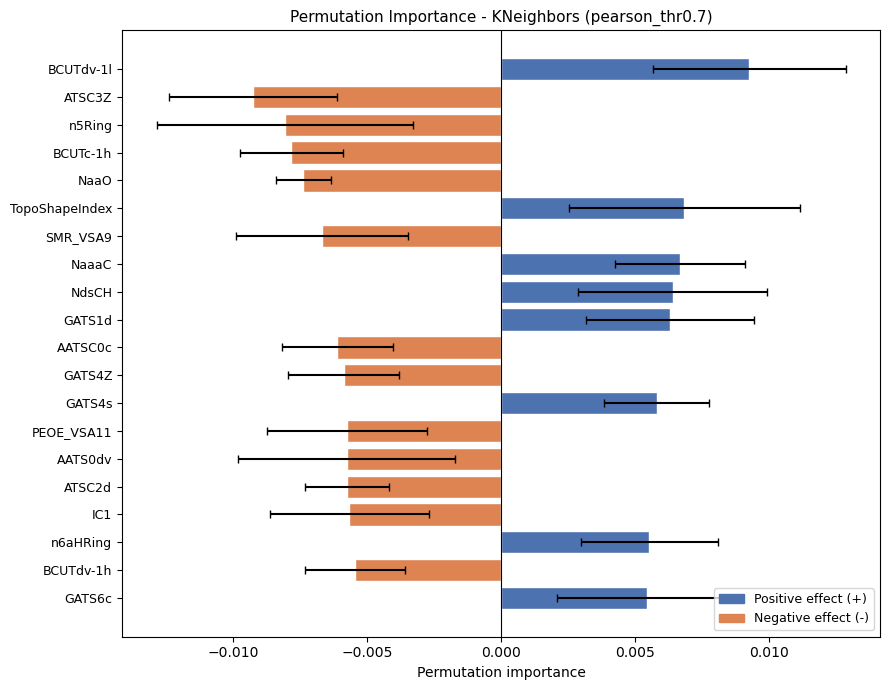

figuras/mordred/paso9_permutation_importance_top1_KNeighbors_mordred.png guardado.

[2/3] Permutation importance: GradientBoosting | pearson_thr0.7 (317 descriptors)
Top 20 descriptors by importance (ROC-AUC):
 descriptor  importance_mean  importance_std       effect
     ATSC2d         0.045579        0.025708 negativo (-)
      VR1_A         0.033046        0.012471 positivo (+)
     GATS4Z         0.029163        0.014179 negativo (-)
EState_VSA2         0.021272        0.013488 positivo (+)
     ATSC8i         0.006734        0.002886 positivo (+)
EState_VSA9         0.006388        0.008926 negativo (-)
     ATSC3s         0.006204        0.005257 negativo (-)
      VE1_A         0.006071        0.002847 positivo (+)
     ATSC6c         0.005688        0.003588 positivo (+)
VSA_EState7         0.005298        0.003979 positivo (+)
     ATSC3i         0.004907        0.002357 negativo (-)
   BCUTd-1l         0.004863        0.002362 negativo (-)
   BCUTc-1h         0.004767        

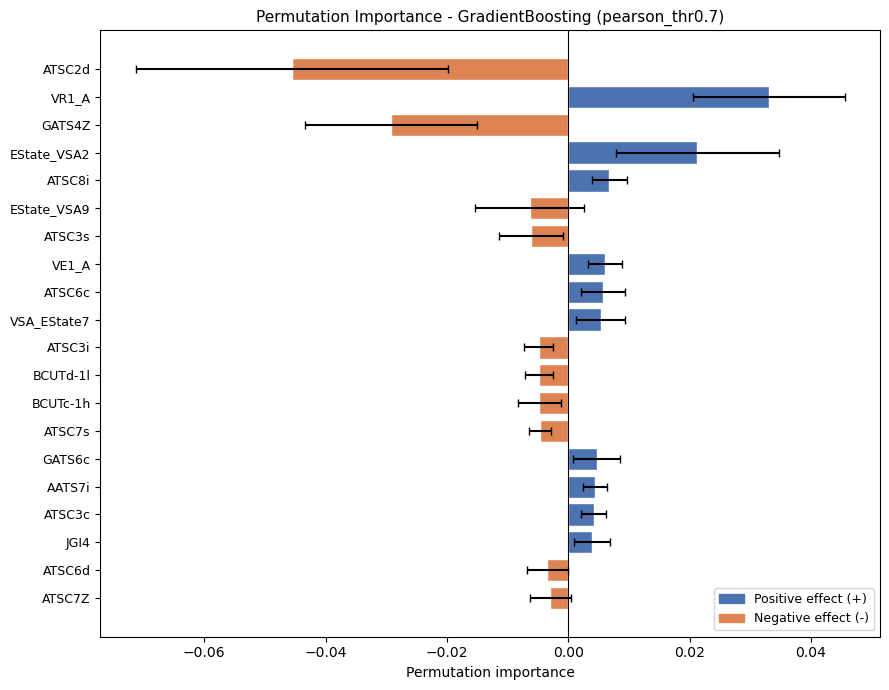

figuras/mordred/paso9_permutation_importance_top2_GradientBoosting_mordred.png guardado.

[3/3] Permutation importance: ExtraTrees | pearson_thr0.7 (317 descriptors)
Top 20 descriptors by importance (ROC-AUC):
 descriptor  importance_mean  importance_std       effect
   n9FARing         0.003264        0.002030 negativo (-)
      NdsCH         0.002166        0.005097 positivo (+)
EState_VSA2         0.001569        0.002252 positivo (+)
      NaaaC         0.001488        0.001709 positivo (+)
     GATS5c         0.001474        0.001064 positivo (+)
     ATSC6s         0.001452        0.001606 negativo (-)
     ATSC6Z         0.001356        0.001118 positivo (+)
     ATSC7s         0.001348        0.001064 negativo (-)
     GATS4Z         0.001341        0.001327 negativo (-)
  PEOE_VSA3         0.001312        0.001259 negativo (-)
 PEOE_VSA11         0.001172        0.002276 negativo (-)
       NsOH         0.001164        0.000795 negativo (-)
     GATS4s         0.000980        

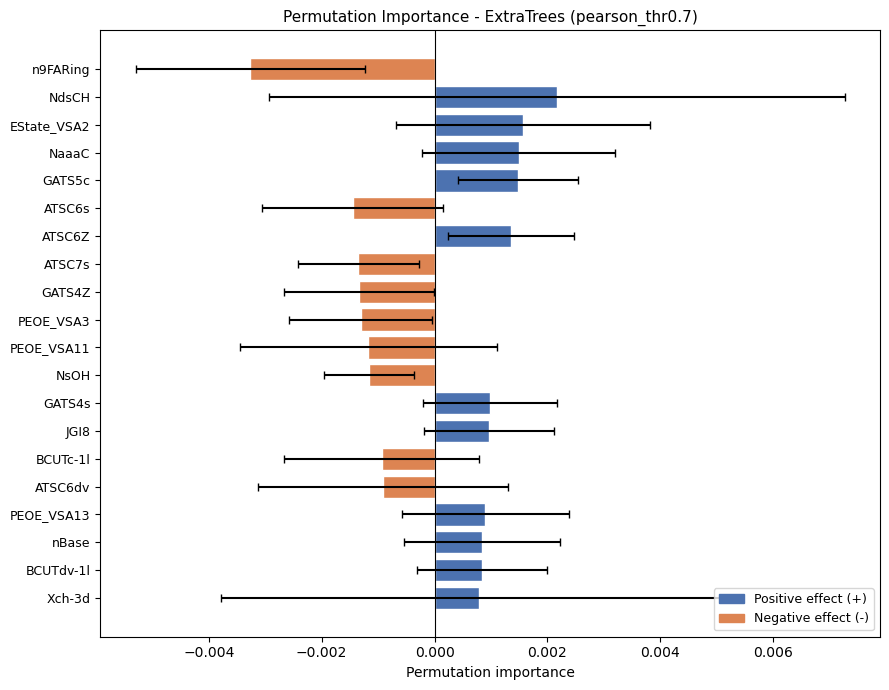

figuras/mordred/paso9_permutation_importance_top3_ExtraTrees_mordred.png guardado.

paraso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos del feature set ganador (pearson_thr0.7).


In [36]:

# La importancia por permutacion mide cuanto empeora el rendimiento del
# modelo (ROC-AUC) al barajar aleatoriamente los valores de un descriptor,
# rompiendo su relacion con la actividad. Se calcula sobre el TEST SET (no
# sobre train), para que refleje la contribucion real del descriptor a la
# capacidad de generalizacion, no a su ajuste a los datos de entrenamiento.
#
# La importancia por permutacion solo mide MAGNITUD (cuanto importa), no
# DIRECCION (si el descriptor favorece o penaliza la actividad). Para
# estimar la direccion se calcula la correlacion de Pearson entre el valor
# del descriptor y la probabilidad predicha por el propio modelo en el test
# set: correlacion positiva -> el descriptor aumenta la probabilidad de
# actividad; correlacion negativa -> la reduce. Es una aproximacion (no
# capta relaciones no monotonas), pero es el criterio habitual en QSAR
# cuando se usan modelos no lineales que no tienen coeficientes directos.
#
# En el grafico, la barra se dibuja hacia la DERECHA si el descriptor tiene
# efecto positivo sobre la actividad y hacia la IZQUIERDA si tiene efecto
# negativo (importancia con signo = importancia * signo de la correlacion).
#
# Se reutilizan los mismos TOP 3 modelos (top3) y el mismo feature set
# ganador (best_fs_name / fs_cols) ya seleccionados en la seccion anterior.

N_TOP_DESCRIPTORS = 20
N_REPEATS_PI       = 30

def permutation_importance_report(model_name, est, fs_name, feat_cols, X_te, y_te,
                                   n_repeats=N_REPEATS_PI, random_state=42):
    result = permutation_importance(
        est, X_te[feat_cols], y_te,
        scoring="roc_auc",
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    if hasattr(est, "predict_proba"):
        y_prob = est.predict_proba(X_te[feat_cols])[:, 1]
    else:
        y_prob = est.decision_function(X_te[feat_cols])

    directions = []
    for col in feat_cols:
        col_vals = X_te[col].values
        if np.std(col_vals) == 0:
            directions.append(0.0)
        else:
            r, _ = pearsonr(col_vals, y_prob)
            directions.append(r)

    imp_df = pd.DataFrame({
        "descriptor"     : feat_cols,
        "importance_mean": result.importances_mean,
        "importance_std" : result.importances_std,
        "direction_corr" : directions,
    })
    imp_df["sign"] = np.where(imp_df["direction_corr"] >= 0, 1, -1)
    imp_df["signed_importance"] = imp_df["importance_mean"] * imp_df["sign"]
    imp_df["effect"] = np.where(imp_df["direction_corr"] >= 0, "positivo (+)", "negativo (-)")
    imp_df = imp_df.reindex(
        imp_df["importance_mean"].sort_values(ascending=False).index
    ).reset_index(drop=True)
    imp_df.insert(0, "model", model_name)
    imp_df.insert(1, "feature_set", fs_name)
    return imp_df


all_importance_dfs = []

for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{best_fs_name}"
    est        = best_estimators[key]

    print("\n" + "=" * 60)
    print(f"[{rank}/3] Permutation importance: {model_name} | {best_fs_name} ({len(fs_cols)} descriptors)")
    print("=" * 60)

    imp_df = permutation_importance_report(model_name, est, best_fs_name, fs_cols, X_test_full, y_test)
    all_importance_dfs.append(imp_df)

    top_n = imp_df.head(N_TOP_DESCRIPTORS)
    out_csv = f'{OUTPUT_DIR_INT}/paso9_permutation_importance_top{rank}_{model_name}.csv'
    imp_df.to_csv(out_csv, index=False)
    print(f"Top {N_TOP_DESCRIPTORS} descriptors by importance (ROC-AUC):")
    print(top_n[["descriptor", "importance_mean", "importance_std", "effect"]].to_string(index=False))
    print(f"{out_csv} guardado.")

    # Orden visual: de mayor a menor importancia absoluta, de arriba a abajo
    top_n_plot = top_n.iloc[::-1]
    colors = np.where(top_n_plot["sign"] > 0, "#4C72B0", "#DD8452")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_n_plot))))
    y_pos = np.arange(len(top_n_plot))
    ax.barh(y_pos, top_n_plot["signed_importance"],
            xerr=top_n_plot["importance_std"],
            color=colors, edgecolor="white", capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_n_plot["descriptor"], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Permutation importance")
    ax.set_title(f"Permutation Importance - {model_name} ({best_fs_name})"
                , fontsize=11)
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="Positive effect (+)"),
        plt.Rectangle((0, 0), 1, 1, color="#DD8452", label="Negative effect (-)"),
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
    plt.tight_layout()
    out_png = f'{FIGURAS}/paso9_permutation_importance_top{rank}_{model_name}_mordred.png'
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_png} guardado.")

df_importance_all = pd.concat(all_importance_dfs, ignore_index=True)
df_importance_all.to_csv(f'{OUTPUT_DIR_INT}/paso9_permutation_importance_all.csv', index=False)
print(f"\nparaso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos "
      f"del feature set ganador ({best_fs_name}).")


# 6. Guardado de los 3 mejores modelos como archivos .joblib

In [38]:
import joblib
import os

ARTIFACTS_DIR = "modelos_joblib_mordred"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

LABEL_MEANING = {
    "1": "Activo (IC50 < 5 uM frente a Falcipaina-2)",
    "0": "Inactivo (IC50 >= 5 uM frente a Falcipaina-2)",
}

# --- Metodo y umbral de correlacion del feature set ganador (parseado del nombre) ---
# fs_name tiene forma "pearson_thr0.7" o "spearman_thr0.9" o "no_filter"
if "_thr" in fs_name:
    correlation_method, thr_str = fs_name.split("_thr")
    correlation_threshold = float(thr_str)
else:
    correlation_method, correlation_threshold = None, None

# --- Top 3 pipelines como DICCIONARIO nombre_modelo -> pipeline (no lista) ---
top3_pipelines = {
    row["model"]: best_estimators[f"{row['model']}__{fs_name}"]
    for _, row in top3.iterrows()
}

mordred_bundle = {
    "descriptor_type": "mordred",
    "feature_columns": fs_cols,
    "feature_medians": X_train_full[fs_cols].median(),
    "top3_models": top3_pipelines,
    "top3_ranking": top3.to_dict("records"),
    "ad_scaler": scaler_ad,
    "ad_nn": nn_ad,
    "ad_threshold": threshold,
    "ad_n_neighbors": 5,
    "background_sample": X_train_full[fs_cols].sample(
        min(100, len(X_train_full)), random_state=42),
    "label_meaning": LABEL_MEANING,
    "correlation_method": correlation_method,
    "correlation_threshold": correlation_threshold,
}

out_path = os.path.join(ARTIFACTS_DIR, "mordred_bundle.joblib")
joblib.dump(mordred_bundle, out_path)
print(f"Guardado: {out_path}")
print(f"Claves del bundle: {list(mordred_bundle.keys())}")

Guardado: modelos_joblib_mordred\mordred_bundle.joblib
Claves del bundle: ['descriptor_type', 'feature_columns', 'feature_medians', 'top3_models', 'top3_ranking', 'ad_scaler', 'ad_nn', 'ad_threshold', 'ad_n_neighbors', 'background_sample', 'label_meaning', 'correlation_method', 'correlation_threshold']
